#Import Depedencies

In [ ]:
!pip install pmdarima
!pip install keras-tuner
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from google.colab import drive
from tensorflow.keras.models import clone_model
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input
from keras.callbacks import EarlyStopping
from keras_tuner.tuners import RandomSearch
from tensorflow.keras.models import load_model
import os
import shutil
# import streamlit as st
from datetime import date, timedelta, datetime
# from plotly import graph_objs as go
import joblib
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.9 MB/s eta 0:00:00


# Beras Premium


#Data Preprocessing

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
harga_2022 = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-2022.xlsx", sheet_name = 1)
harga_2023 = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-2023.xlsx", sheet_name = 1)
harga_2024 = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-2024.xlsx", sheet_name = 1)

In [ ]:
hrg_22 = harga_2022.copy()
hrg_22 = hrg_22.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
hrg_22 = hrg_22[['tanggal','beras_premium', 'beras_medium']]
hrg_22.head()

,tanggal,beras_premium,beras_medium
0,01/01/2022,12720,11290
1,02/01/2022,12710,11400
2,03/01/2022,12510,11360
3,04/01/2022,12450,11300
4,05/01/2022,12430,11200


In [ ]:
hrg_23 = harga_2023.copy()
hrg_23 = hrg_23.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
hrg_23 = hrg_23[['tanggal','beras_premium', 'beras_medium']]
hrg_23.head()

,tanggal,beras_premium,beras_medium
0,01/01/2023,12890,11710
1,02/01/2023,12910,11800
2,03/01/2023,12870,11740
3,04/01/2023,12900,11790
4,05/01/2023,12890,11800


In [ ]:
hrg_24 = harga_2024.copy()
hrg_24 = hrg_24.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
hrg_24 = hrg_24[['tanggal','beras_premium', 'beras_medium']]
hrg_24.head()

,tanggal,beras_premium,beras_medium
0,01/01/2024,14680,13590
1,02/01/2024,14680,13630
2,03/01/2024,14710,13640
3,04/01/2024,14710,13620
4,05/01/2024,14700,13660


In [ ]:
df_beras = pd.concat([hrg_22, hrg_23, hrg_24], ignore_index = True)
df_beras.tail(14)

,tanggal,beras_premium,beras_medium
868,18/05/2024,15230,13920
869,19/05/2024,15310,13950
870,20/05/2024,15320,13960
871,21/05/2024,15320,13940
872,22/05/2024,15320,13940
873,23/05/2024,15280,13920
874,24/05/2024,15330,13970
875,25/05/2024,15310,13980
876,26/05/2024,15310,13930
877,27/05/2024,15250,13900


In [ ]:
df_beras.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tanggal        882 non-null    object
 1   beras_premium  882 non-null    object
 2   beras_medium   882 non-null    object
dtypes: object(3)
memory usage: 20.8+ KB


In [ ]:
df_premium = df_beras[['tanggal', 'beras_premium']].copy()
df_medium = df_beras[['tanggal', 'beras_medium']].copy()

In [ ]:
df_medium.head()

,tanggal,beras_medium
0,01/01/2022,11290
1,02/01/2022,11400
2,03/01/2022,11360
3,04/01/2022,11300
4,05/01/2022,11200


In [ ]:
df_premium['tanggal'] = pd.to_datetime(df_premium['tanggal'], dayfirst=True)
df_medium['tanggal'] = pd.to_datetime(df_medium['tanggal'], dayfirst=True)
df_premium[['beras_premium']] = df_premium[['beras_premium']].replace('-', np.nan)
df_medium[['beras_medium']] = df_medium[['beras_medium']].replace('-', np.nan)

<ipython-input-11-faab86d6821a>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_premium[['beras_premium']] = df_premium[['beras_premium']].replace('-', np.nan)
<ipython-input-11-faab86d6821a>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_medium[['beras_medium']] = df_medium[['beras_medium']].replace('-', np.nan)


In [ ]:
df_premium.set_index('tanggal', inplace=True)
df_medium.set_index('tanggal', inplace=True)

In [ ]:
df_premium = df_premium.asfreq('D')
df_medium = df_medium.asfreq('D')

In [ ]:
df_premium = df_premium.loc['2022-07-15':].copy()
df_medium = df_medium.loc['2022-07-15':].copy()

Mengisi null value menggunakan teknik interpolasi

https://www.geeksforgeeks.org/how-to-deal-with-missing-values-in-a-timeseries-in-python/

In [ ]:
df_premium['beras_premium'] = df_premium['beras_premium'].interpolate(method='linear')

In [ ]:
df_medium['beras_medium'] = df_medium['beras_medium'].interpolate(method='linear')

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
df_premium = df_premium.astype({'beras_premium': int})
df_medium = df_medium.astype({'beras_medium': int})

In [ ]:
def data_prep(data):
  data['tanggal'] = pd.to_datetime(data['tanggal'], dayfirst=True)
  data[data.columns[1]] = data[data.columns[1]].replace('-', np.nan)
  data.set_index('tanggal', inplace=True)
  data = data.asfreq('D')
  data[data.columns[0]] = data[data.columns[0]].interpolate(method='linear')
  data = data.astype({data.columns[0]: int})
  return data

In [ ]:
df_beras_new = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-baru.xlsx", sheet_name = 1)
df_beras_new = df_beras_new.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
df_premium_new = data_prep(df_beras_new[['tanggal', 'beras_premium']].copy())
df_medium_new = data_prep(df_beras_new[['tanggal', 'beras_medium']].copy())

<ipython-input-20-ca06cd6b7477>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[data.columns[1]] = data[data.columns[1]].replace('-', np.nan)
<ipython-input-20-ca06cd6b7477>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[data.columns[1]] = data[data.columns[1]].replace('-', np.nan)


In [ ]:
df_premium_new.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 901 entries, 2022-07-15 to 2024-12-31
Freq: D
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   beras_premium  901 non-null    int64
dtypes: int64(1)
memory usage: 14.1 KB


In [ ]:
df_premium.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 687 entries, 2022-07-15 to 2024-05-31
Freq: D
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   beras_premium  687 non-null    int64
dtypes: int64(1)
memory usage: 10.7 KB


In [ ]:
df_medium.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 687 entries, 2022-07-15 to 2024-05-31
Freq: D
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   beras_medium  687 non-null    int64
dtypes: int64(1)
memory usage: 10.7 KB


In [ ]:
# avg_daily = df_beras.loc['2022-09-01':'2024-04-02'].resample('D').beras_premium.mean().to_frame()

# sns.relplot(x = avg_daily.index, y=avg_daily.beras_premium, kind='line', aspect = 3, hue=avg_daily.index.year, palette='viridis')
# plt.xlabel('Date')
# plt.ylabel('Harga')
# plt.title('Grafik Harga Beras Premium')

In [ ]:
# plot_acf(df_premium, lags=30)

In [ ]:
df_premium2 = df_premium.copy()
df_premium2['rollMean'] = df_premium2.beras_premium.rolling(window=365,
                                                          min_periods=183,
                                                          center=True).mean()
df_premium2['rollStd'] = df_premium2.beras_premium.rolling(window=365,
                                                         min_periods=183,
                                                         center=True).std()

In [ ]:
df_premium.head()

,beras_premium
tanggal,
2022-07-15,12320
2022-07-16,12270
2022-07-17,12310
2022-07-18,12290
2022-07-19,12250


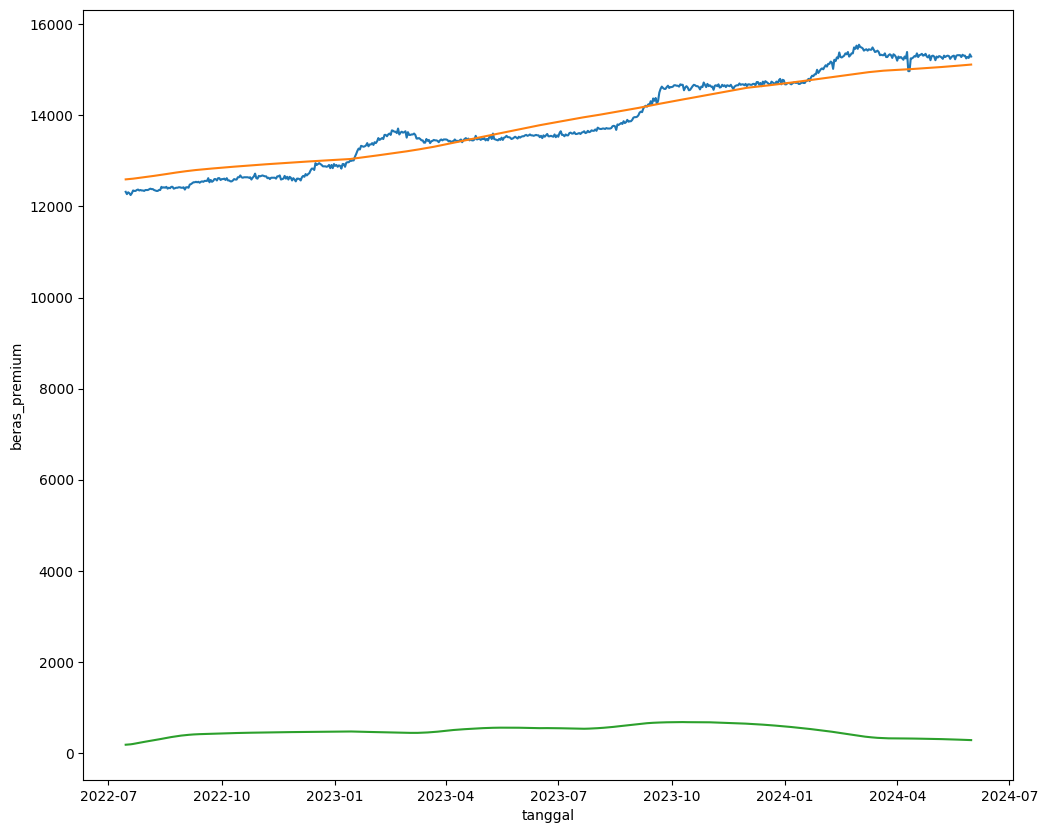

In [ ]:
plt.figure(figsize=(12, 10))
sns.lineplot(data = df_premium2, x = df_premium2.index, y = df_premium2.beras_premium)
sns.lineplot(data = df_premium2, x = df_premium2.index, y = df_premium2.rollMean)
sns.lineplot(data = df_premium2, x = df_premium2.index, y = df_premium2.rollStd)
plt.show()

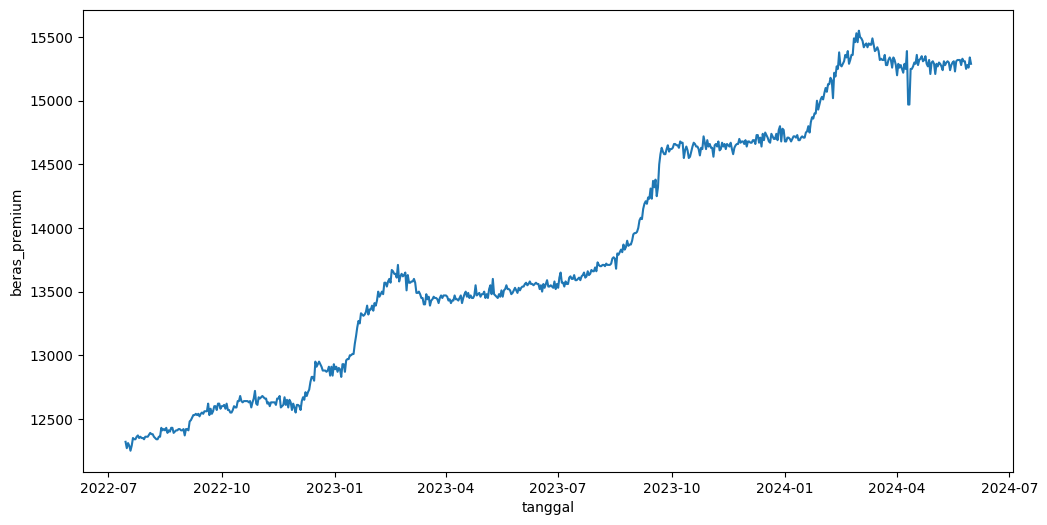

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data = df_premium, x = df_premium.index, y = df_premium.beras_premium)
plt.show()

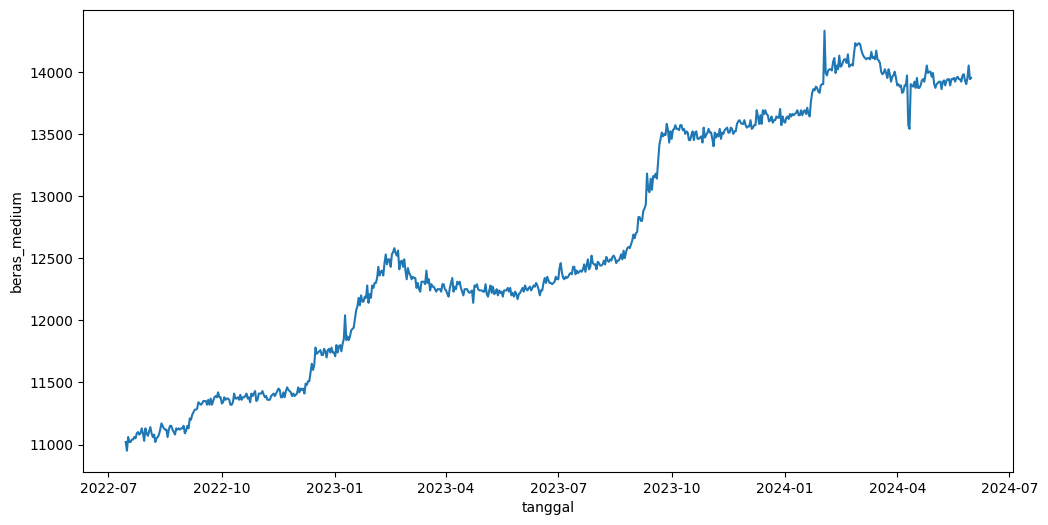

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data = df_medium, x = df_medium.index, y = df_medium.beras_medium)
plt.show()

In [ ]:
import statsmodels.api as sm

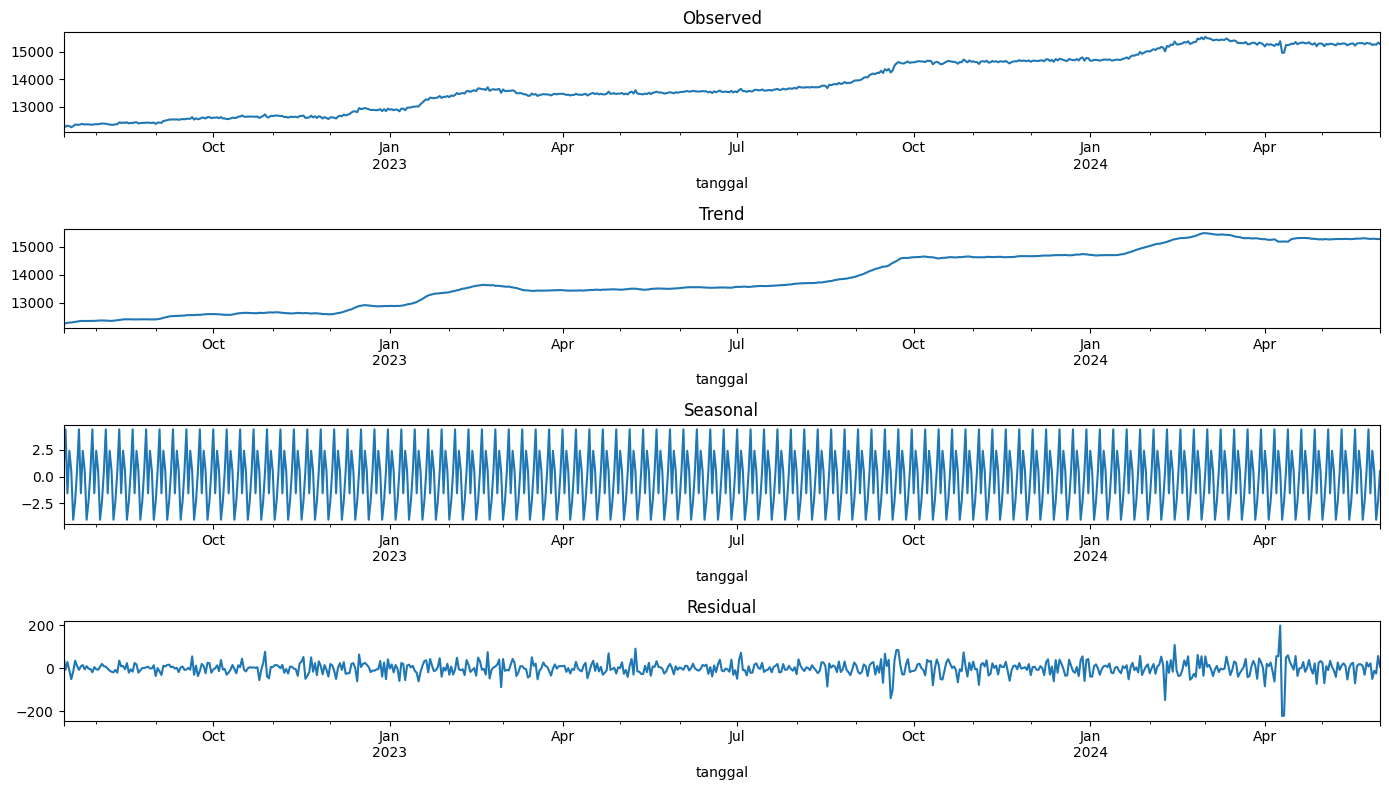

In [ ]:
decomposition = sm.tsa.seasonal_decompose(df_premium, model='additive', extrapolate_trend='freq')
fig, axes = plt.subplots(4, 1, figsize=(14, 8))

# Plotting the decomposed components
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

In [ ]:
# data_resampled = df_premium.resample('2W').mean()

In [ ]:
# data = df_premium.copy()

In [ ]:
# data['Week_Number'] = data.index.isocalendar().week
# data['Day_of_Week'] = data.index.day_name()

In [ ]:
# plt.figure(figsize=(14, 8))
# sns.lineplot(data=data, x='Day_of_Week', y='beras_premium', hue='Week_Number', palette='tab20', legend=False)
# plt.title('Seasonal Plot: Daily Data Grouped by Weeks')
# plt.show()

In [ ]:
def seasonal_plot(X, y, period, freq):
  fig, ax = plt.subplots(figsize=(15, 8))
  palette = sns.color_palette("husl", n_colors=X[period].nunique())
  sns.lineplot(x=freq, y=y, hue=period, data=X, errorbar=None, ax=ax,
                    palette=palette, legend=False)

  ax.set_title(f"Seasonal Plot ({period}/{freq})")
  for line, name in zip(ax.lines, X[period].unique()):
    y_ = line.get_ydata()[-1]
    ax.annotate(name, xy=(1, y_), xytext=(6, 0), color=line.get_color(), size=14,
                xycoords=ax.get_yaxis_transform(), textcoords="offset points", va="center")

  return ax

def plot_periodogram(ts):
    # Menghitung frekuensi sampling dalam satuan hari
    days_per_year = 365.25
    fs = days_per_year  # 1 year in terms of days

    # Menghitung periodogram
    frequencies, spectrum = periodogram(ts, fs=fs, detrend='linear', window="boxcar", scaling='spectrum')

    # Membuat plot
    _, ax = plt.subplots(figsize=(16, 6))
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(["Annual (1)", "Semiannual (2)", "Quarterly (4)",
                        "Bimonthly (6)", "Monthly (12)", "Biweekly (26)",
                        "Weekly (52)", "Semiweekly (104)"], rotation=30)

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")

    return ax

In [ ]:
pr_plot = df_premium.copy()

In [ ]:
pr_plot["dow"] = pr_plot.index.dayofweek  # the x-axis (freq)
pr_plot["week"] = pr_plot.index.isocalendar().week.to_numpy()  # the seasonal period (period)

# days within a year
pr_plot["dayofyear"] = pr_plot.index.dayofyear
pr_plot["year"] = pr_plot.index.year

pr_plot['day'] = pr_plot.index.day
pr_plot['month'] = pr_plot.index.month

In [ ]:
pr_plot.head()

,beras_premium,dow,week,dayofyear,year,day,month
tanggal,,,,,,,
2022-07-15,12320,4,28,196,2022,15,7
2022-07-16,12270,5,28,197,2022,16,7
2022-07-17,12310,6,28,198,2022,17,7
2022-07-18,12290,0,29,199,2022,18,7
2022-07-19,12250,1,29,200,2022,19,7


<Axes: title={'center': 'Seasonal Plot (month/day)'}, xlabel='day', ylabel='beras_premium'>

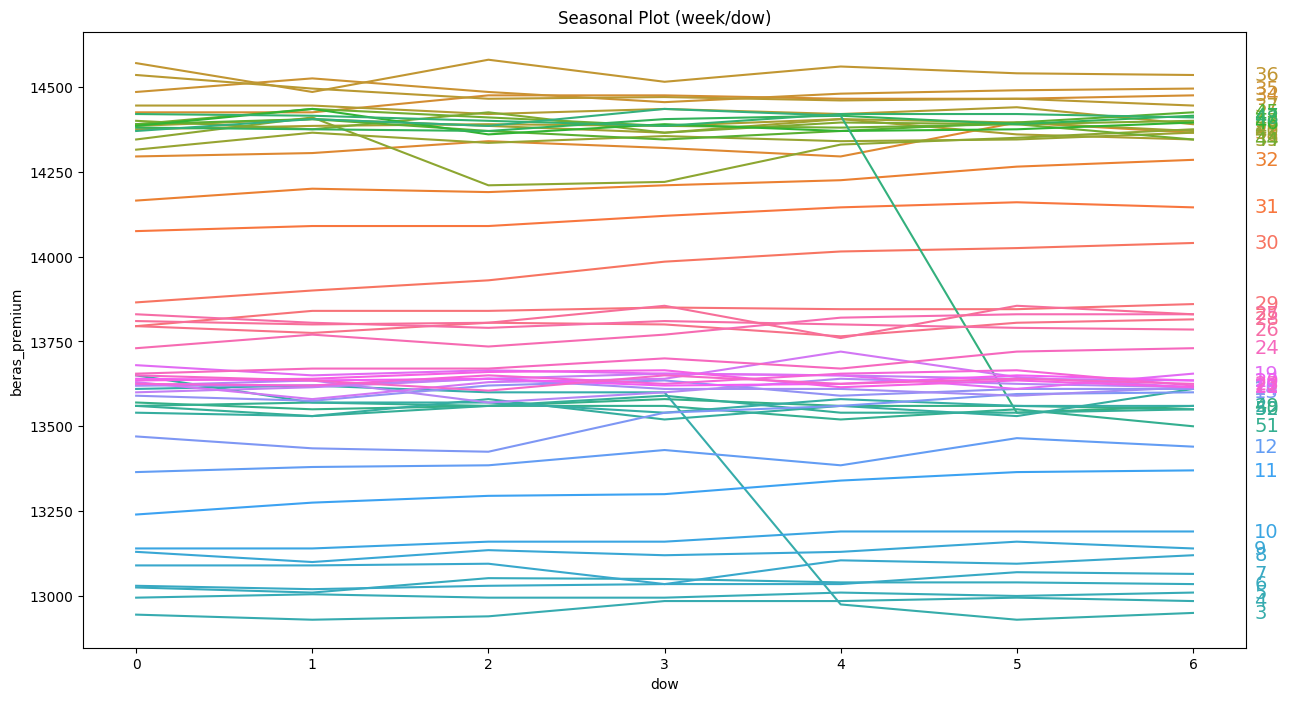

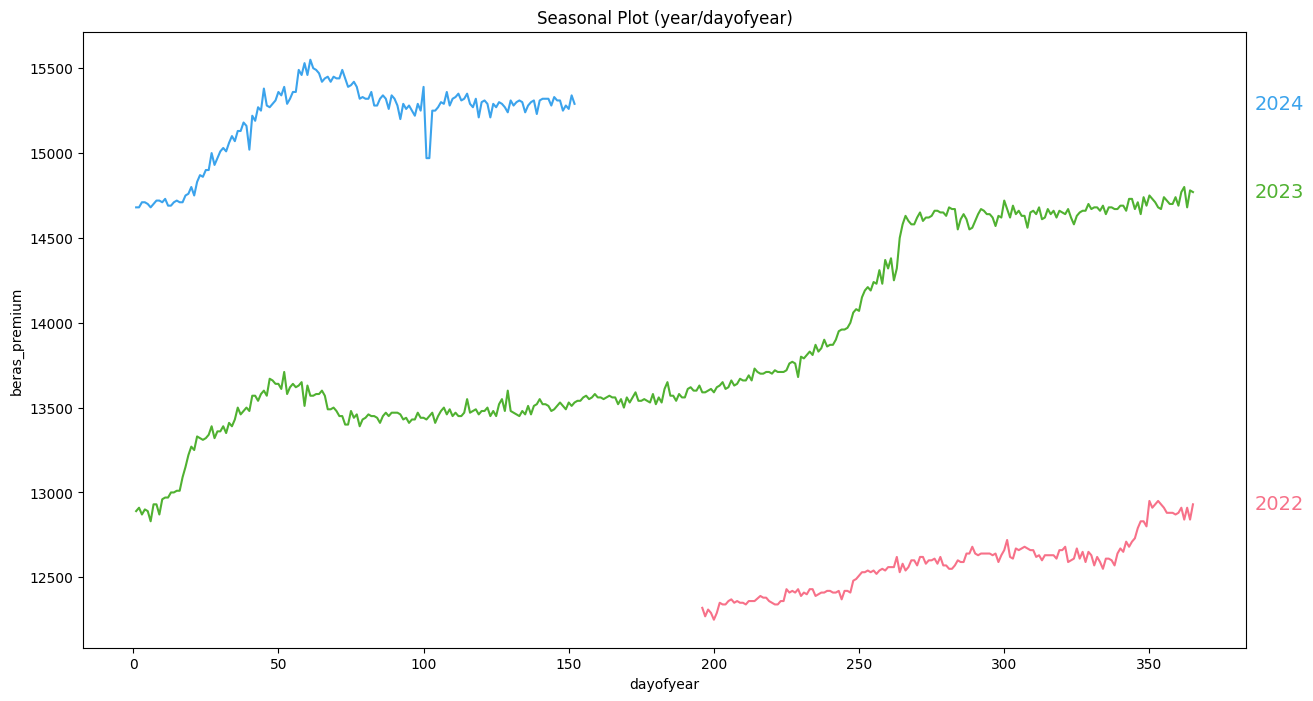

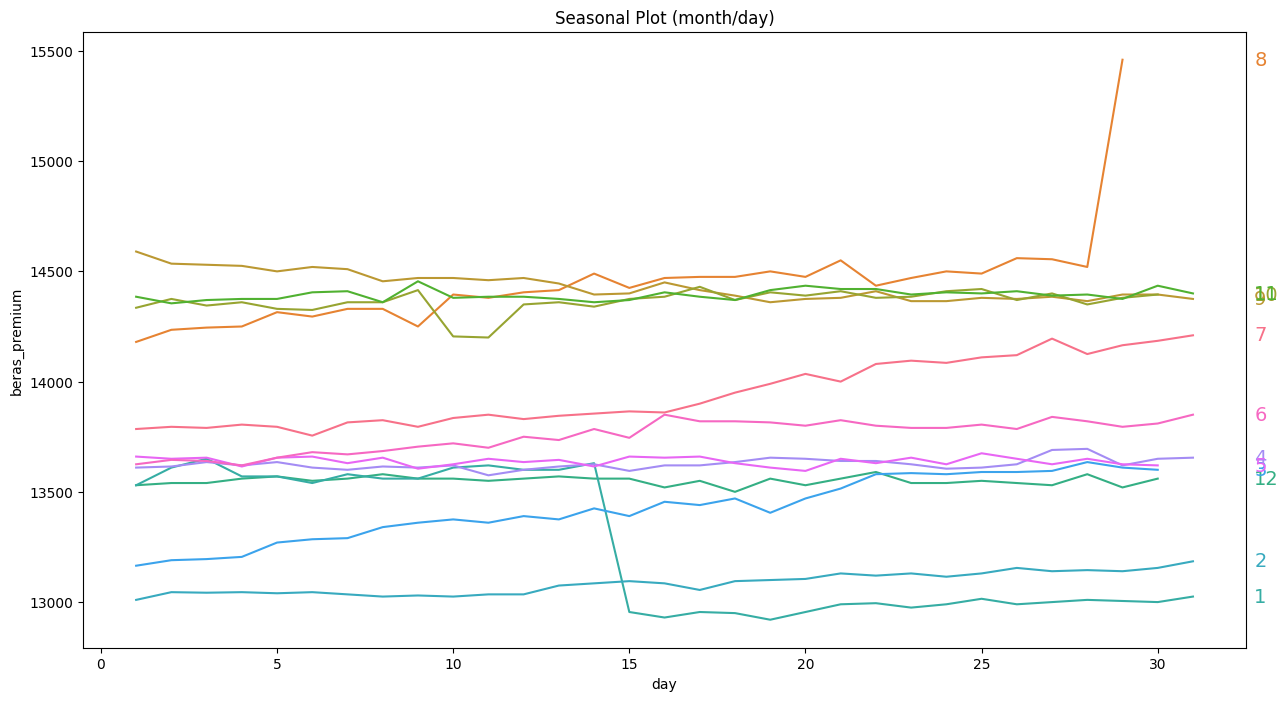

In [ ]:
seasonal_plot(pr_plot, y='beras_premium', period='week', freq='dow')
seasonal_plot(pr_plot, y='beras_premium', period='year', freq='dayofyear')
seasonal_plot(pr_plot, y='beras_premium', period='month', freq='day')

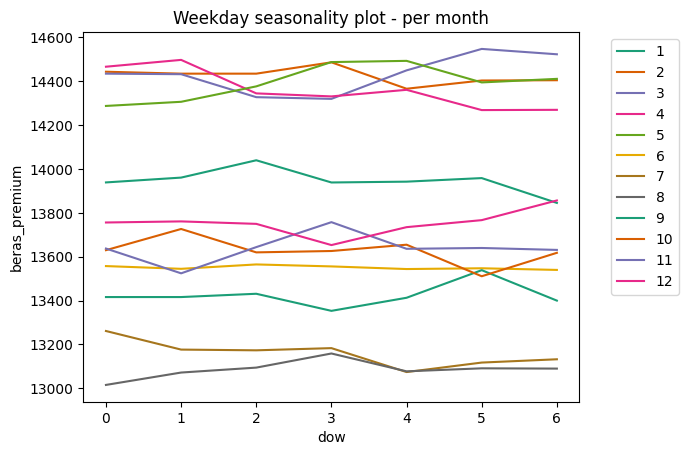

In [ ]:
sns.lineplot(data=pr_plot,
             x='dow',
             y='beras_premium',
             hue='month',
             legend='full',
            palette='Dark2',
             errorbar=None)

# add title
plt.title('Weekday seasonality plot - per month')

# move the legend outside of the main figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2);

Dikarenakan Data memiliki Seasonality maka model yang akan dibangun adalah SARIMAX

In [ ]:
from statsmodels.tsa.stattools import adfuller
adfTest = adfuller(df_premium['beras_premium'],autolag = 'AIC')
adfTest

(-0.5458576036494613,
 0.8827528194872972,
 7,
 679,
 {'1%': -3.4400174432106305,
  '5%': -2.8658060125001295,
  '10%': -2.569041777564251},
 6930.754633871323)

In [ ]:
stats = pd.Series(adfTest[0:4], index = ['Test Statistic',
                                         'p-value',
                                         '#lags used',
                                         'number of observations used'])
stats

,0
Test Statistic,-0.545858
p-value,0.882753
#lags used,7.000000
number of observations used,679.000000


In [ ]:
for key, values in adfTest[4].items():
  print('criticality', key, ': ', values)

criticality 1% :  -3.4400174432106305
criticality 5% :  -2.8658060125001295
criticality 10% :  -2.569041777564251


If  test statistics < criticality then the data is stationary.

Jadi data ini tidak stasioner

menit 28
https://www.youtube.com/watch?v=O5pataOw33Y&t=831s

referensi 2 menit 7:50
https://www.youtube.com/watch?v=2XGSIlgUBDI&t=1077s


# Modelling

## ARIMA

In [ ]:
 from statsmodels.tsa.arima_model import ARIMA
 from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# def adf_test(series):
#     result = adfuller(series.dropna())
#     print('ADF Statistic: %f' % result[0])
#     print('p-value: %f' % result[1])
#     return result

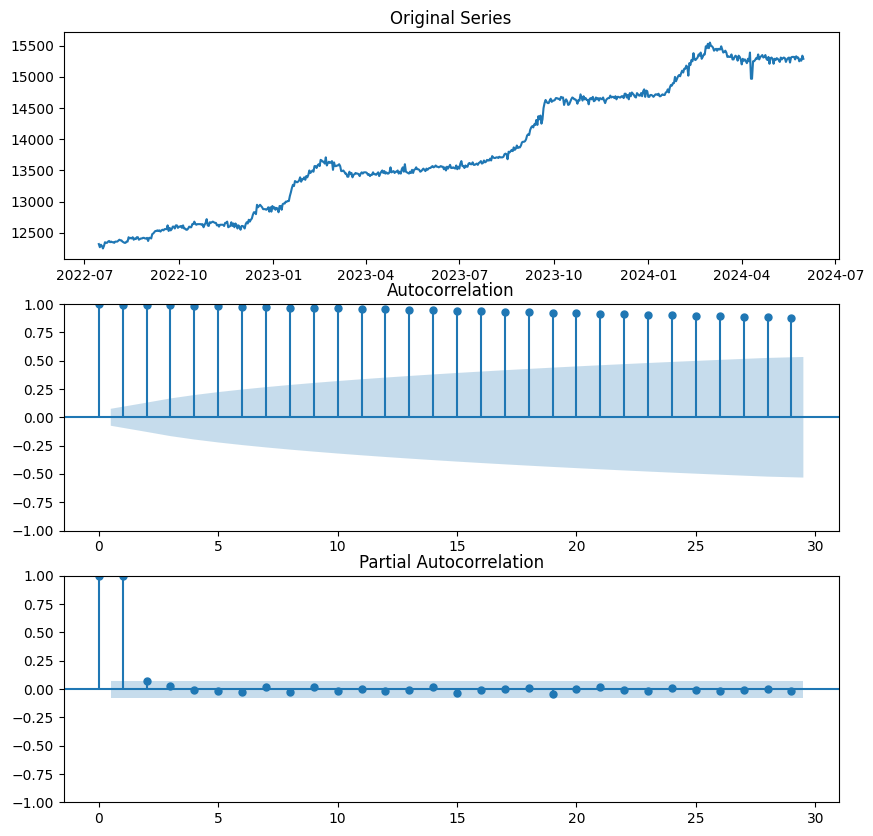

In [ ]:
premium = df_premium.copy()
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(premium)
ax[0].set_title('Original Series')
plot_acf(premium, ax=ax[1])
plot_pacf(premium, ax=ax[2])
plt.show()

In [ ]:
premium.head()

,beras_premium
tanggal,
2022-07-15,12320
2022-07-16,12270
2022-07-17,12310
2022-07-18,12290
2022-07-19,12250


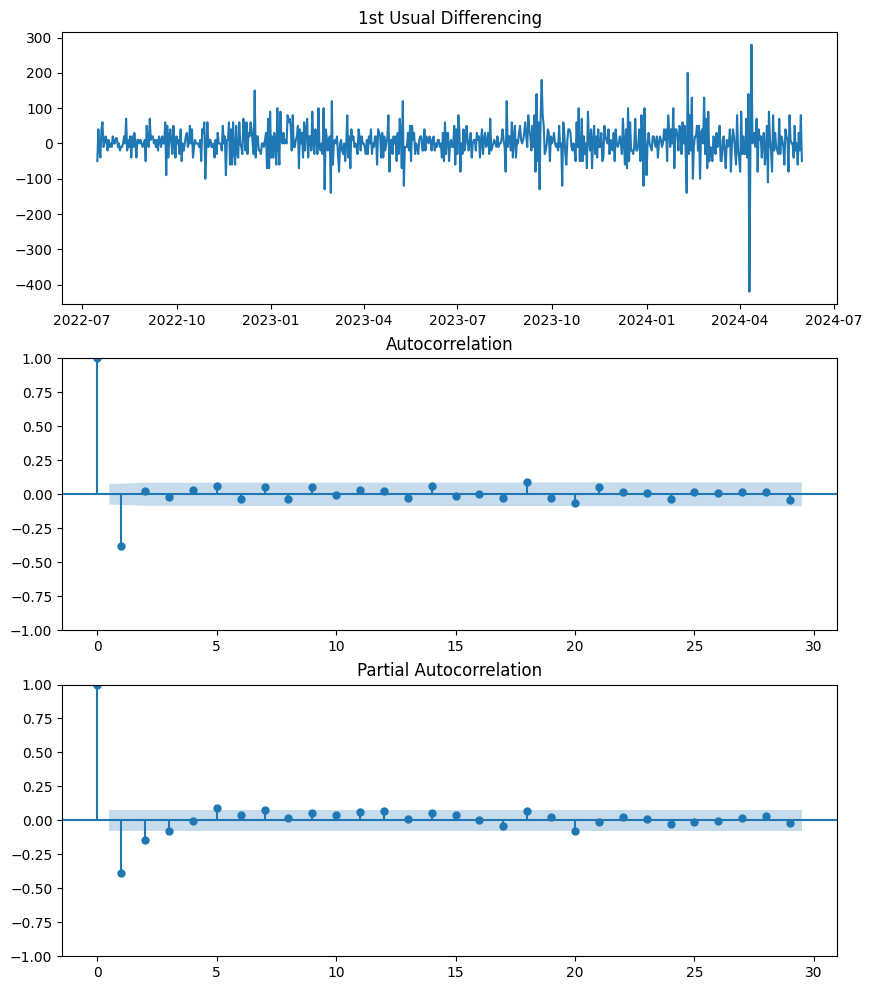

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes[0].plot(premium['beras_premium'].diff().dropna()); axes[0].set_title('1st Usual Differencing')
#axes[1].set(ylim=(0,2))
plot_acf(premium['beras_premium'].diff().dropna(), ax=axes[1])
plot_pacf(premium['beras_premium'].diff().dropna(), ax=axes[2])

plt.show()

In [ ]:
from scipy import stats
premium['beras_premium'], lmd = stats.boxcox(premium['beras_premium'])
adfTestDiff = adfuller(premium['beras_premium'] ,autolag = 'AIC')
adfTestDiff

(-0.7874492200188092,
 0.822780993016903,
 7,
 679,
 {'1%': -3.4400174432106305,
  '5%': -2.8658060125001295,
  '10%': -2.569041777564251},
 -11738.355037534551)

In [ ]:
premium.head()

,beras_premium
tanggal,
2022-07-15,2.118713
2022-07-16,2.118663
2022-07-17,2.118703
2022-07-18,2.118683
2022-07-19,2.118643


In [ ]:
adfTestDiff = adfuller(premium['beras_premium'].diff().dropna() ,autolag = 'AIC')
adfTestDiff

(-8.978350898958377,
 7.42576971809942e-15,
 6,
 679,
 {'1%': -3.4400174432106305,
  '5%': -2.8658060125001295,
  '10%': -2.569041777564251},
 -11721.08853055859)

In [ ]:
statsDiff = pd.Series(adfTestDiff[0:4], index = ['Test Statistic',
                                         'p-value',
                                         '#lags used',
                                         'number of observations used'])
statsDiff

,0
Test Statistic,-8.978351e+00
p-value,7.425770e-15
#lags used,6.000000e+00
number of observations used,6.790000e+02


In [ ]:
 from statsmodels.tsa.arima.model import ARIMA

In [ ]:
train_pm = premium[:-14]
train_pm2 = df_premium[:-14]
# train_pm2 = df_premium[:math.floor(len(df_premium)*0.85)]
train_pm.tail()

,beras_premium
tanggal,
2024-05-13,2.121267
2024-05-14,2.121223
2024-05-15,2.121253
2024-05-16,2.121267
2024-05-17,2.121275


In [ ]:
test_pm = premium[-14:]
test_pm2 = df_premium[-14:]
# test_pm2 = df_premium[math.floor(len(df_premium)*0.85):]
test_pm.head()

,beras_premium
tanggal,
2024-05-18,2.121216
2024-05-19,2.121275
2024-05-20,2.121282
2024-05-21,2.121282
2024-05-22,2.121282


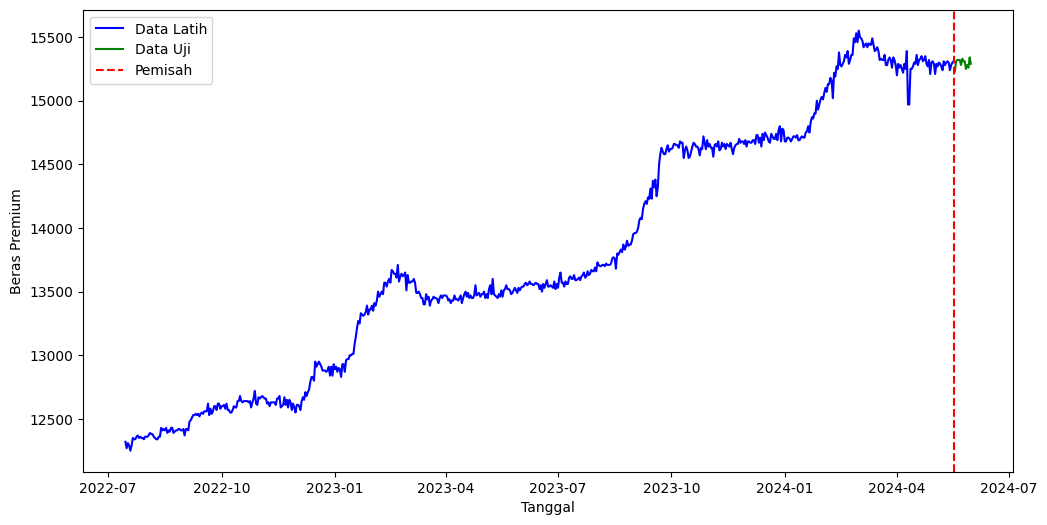

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data = train_pm2, x = train_pm2.index, y = train_pm2.beras_premium, color='blue', label='Data Latih')
sns.lineplot(data = test_pm2, x = test_pm2.index, y = test_pm2.beras_premium, color='green', label='Data Uji')
plt.axvline(train_pm2[-1:].index, color="red", linestyle="--", label="Pemisah")
plt.legend()
plt.xlabel("Tanggal")
plt.ylabel("Beras Premium")
# plt.grid(alpha=0.5)
plt.show()


In [ ]:
model_pm = ARIMA(train_pm['beras_premium'], order=(2,1,1))
model_pm_fit = model_pm.fit()

In [ ]:
result_am = premium.copy()
am_pred = model_pm_fit.predict(start = test_pm.index[0], end = test_pm.index[-1])
am_pred2 = model_pm_fit.predict(start = train_pm.index[0], end = train_pm.index[-1])
result_am['test_pred'] = am_pred
result_am['train_pred'] = am_pred2

In [ ]:
am_pred2.head()

,predicted_mean
tanggal,
2022-07-15,0.000000
2022-07-16,2.118713
2022-07-17,2.118682
2022-07-18,2.118691
2022-07-19,2.118687


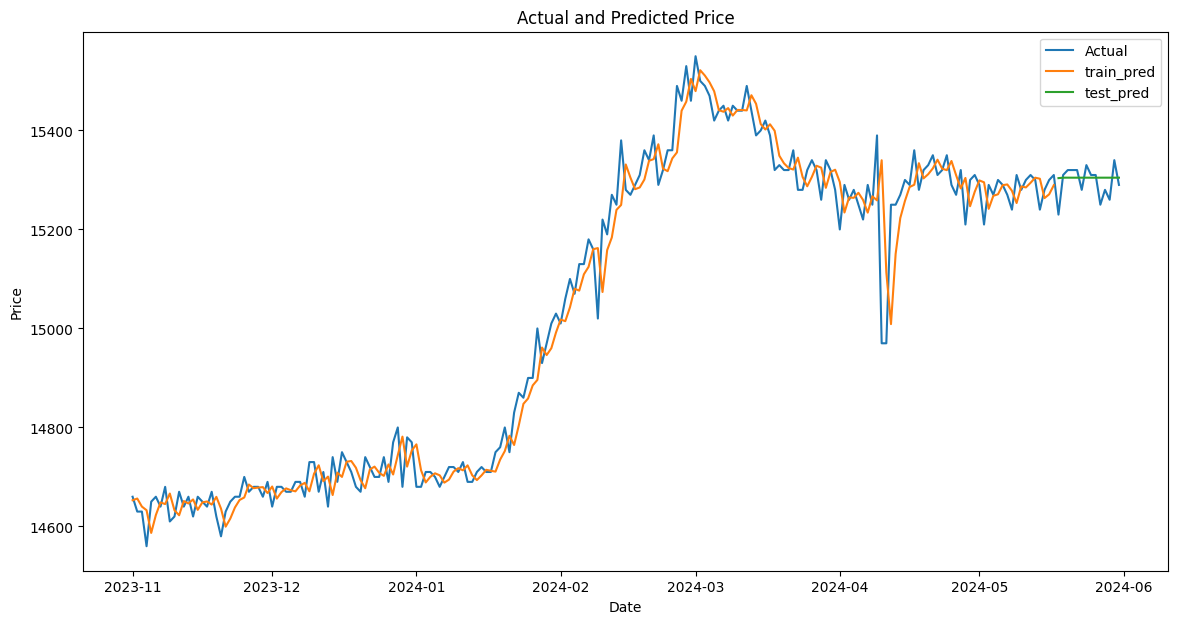

In [ ]:
from scipy.special import inv_boxcox
plt.figure(figsize=(14, 7))
subset_data = inv_boxcox(result_am.loc['2023-11':], lmd)
sns.lineplot(data=subset_data, x=subset_data.index, y='beras_premium', label='Actual')
sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred', label='train_pred')
sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred', label='test_pred')

plt.title('Actual and Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
result_am.head()

,beras_premium,test_pred,train_pred
tanggal,,,
2022-07-15,2.118713,NaN,0.000000
2022-07-16,2.118663,NaN,2.118713
2022-07-17,2.118703,NaN,2.118682
2022-07-18,2.118683,NaN,2.118691
2022-07-19,2.118643,NaN,2.118687


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def arima_error(actual, pred):
  mae = mean_absolute_error(actual, pred)
  mape = mean_absolute_percentage_error(actual, pred) * 100

  return({'MAE' : mae,
          'MAPE' : mape})


In [ ]:
print(f"Train Error : {arima_error(inv_boxcox(train_pm['beras_premium'], lmd)[1:], inv_boxcox(am_pred2, lmd)[1:])}")
print(f"Test Error : {arima_error(inv_boxcox(test_pm['beras_premium'], lmd), inv_boxcox(am_pred, lmd))}")

Train Error : {'MAE': 30.846179027528944, 'MAPE': 0.2212777155583514}
Test Error : {'MAE': 25.702067477294413, 'MAPE': 0.16821895532003844}


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
adfTestDiff2 = adfuller(premium['beras_premium'].diff().diff(7).dropna() ,autolag = 'AIC')
statsDiff2 = pd.Series(adfTestDiff2[0:4], index = ['Test Statistic',
                                         'p-value',
                                         '#lags used',
                                         'number of observations used'])
statsDiff2

,0
Test Statistic,-7.864258e+00
p-value,5.185297e-12
#lags used,2.000000e+01
number of observations used,6.580000e+02


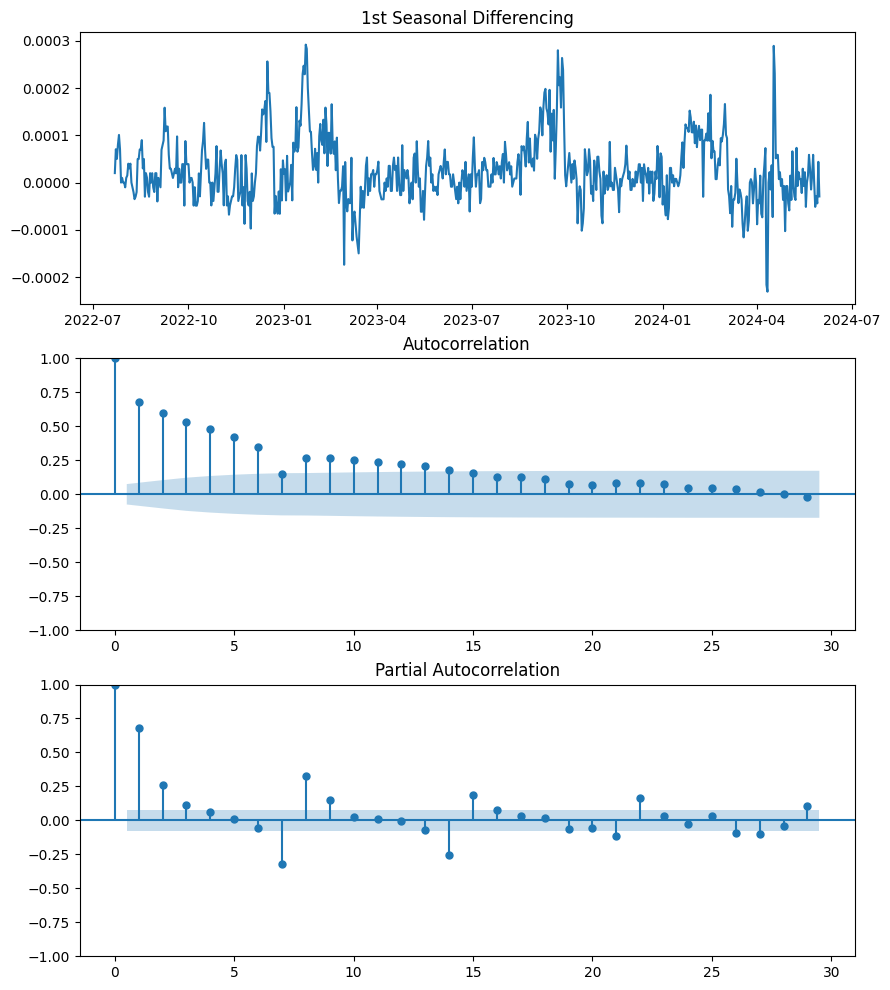

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes[0].plot(premium['beras_premium'].diff(7).dropna()); axes[0].set_title('1st Seasonal Differencing')
plot_acf(premium['beras_premium'].diff(7).dropna(), ax=axes[1])
plot_pacf(premium['beras_premium'].diff(7).dropna(), ax=axes[2])

plt.show()

In [ ]:
# premium['seasonalDiff'] = premium['beras_premium'].diff().diff(7)

In [ ]:
model_pm2 = SARIMAX(train_pm['beras_premium'], order = (3,1,1), seasonal_order = (4,1,1,7))
model_pm2_fit = model_pm2.fit()

In [ ]:
sm_pred = model_pm2_fit.predict(start = test_pm.index[0], end = test_pm.index[-1])
# sm_pred = model_pm2_fit.forecast(step=200)
sm_pred2 = model_pm2_fit.predict(start = train_pm.index[0], end = train_pm.index[-1])
result_sm = premium.copy()
result_sm['test_pred'] = sm_pred
result_sm['train_pred'] = sm_pred2

In [ ]:
result_sm.head(8)

,beras_premium,test_pred,train_pred
tanggal,,,
2022-07-15,2.118713,NaN,0.000000
2022-07-16,2.118663,NaN,2.118713
2022-07-17,2.118703,NaN,2.118663
2022-07-18,2.118683,NaN,2.118703
2022-07-19,2.118643,NaN,2.118683
2022-07-20,2.118683,NaN,2.118643
2022-07-21,2.118744,NaN,2.118683
2022-07-22,2.118734,NaN,3.178100


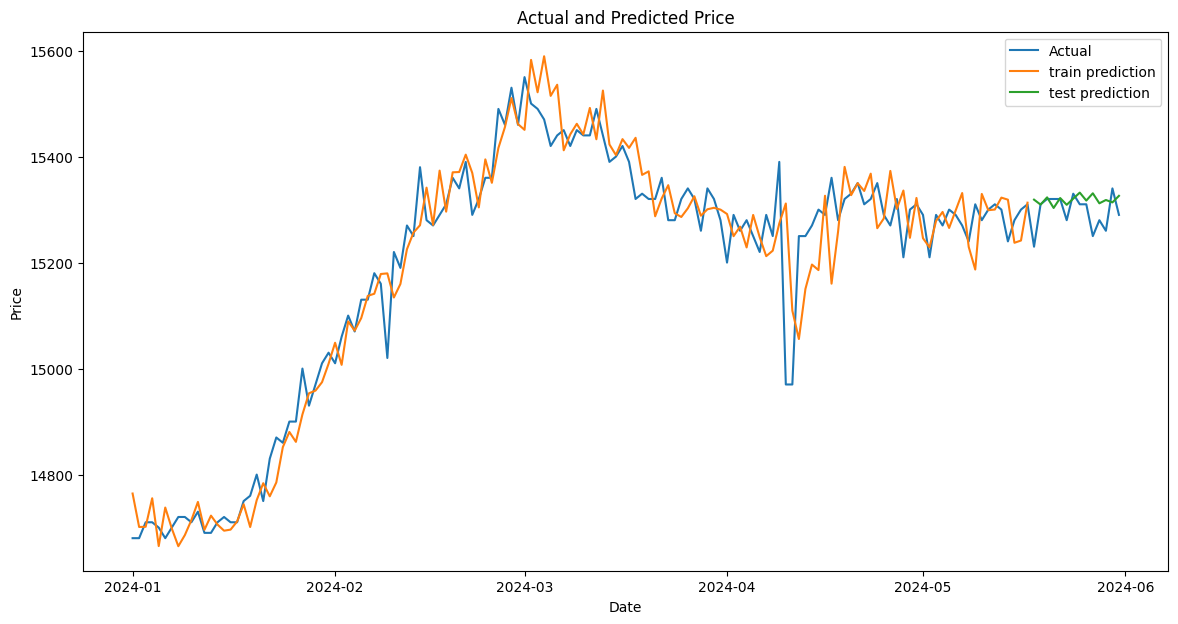

In [ ]:
plt.figure(figsize=(14, 7))
subset_data = inv_boxcox(result_sm.loc['2024-01':], lmd)
sns.lineplot(data=subset_data, x=subset_data.index, y='beras_premium', label='Actual')
sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred', label='train prediction')
sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred', label='test prediction')

plt.title('Actual and Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
print(f"Train Error : {arima_error(inv_boxcox(train_pm['beras_premium'], lmd)[8:], inv_boxcox(sm_pred2, lmd)[8:])}")
print(f"Test Error : {arima_error(inv_boxcox(test_pm['beras_premium'], lmd), inv_boxcox(sm_pred, lmd))}")

Train Error : {'MAE': 34.38800308679484, 'MAPE': 0.24672047903916447}
Test Error : {'MAE': 29.409386846627577, 'MAPE': 0.19258849737444195}


###Finding Best Parameters for SARIMAX


In [ ]:
premium.head()

,beras_premium
tanggal,
2022-07-15,2.118713
2022-07-16,2.118663
2022-07-17,2.118703
2022-07-18,2.118683
2022-07-19,2.118643


In [ ]:
import pmdarima as pm

def auto_arima(x_train):
  model_auto = pm.auto_arima(x_train,
                             seasonal=True,
                             m=7,
                             d=None,
                             D=None,
                             with_intercept=False,
                             start_q=0,
                             max_p=2, max_q=1,
                             max_P=3, max_Q=6,
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=False)

  print(model_auto.summary())
  return model_auto

In [ ]:
model_auto = auto_arima(train_pm)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-11725.595, Time=0.20 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,1)[7]             : AIC=-11725.773, Time=0.98 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,1,1)(1,0,0)[7]             : AIC=-11827.658, Time=0.85 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(1,0,1)[7]             : AIC=-11825.767, Time=0.64 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(2,0,0)[7]             : AIC=-11827.886, Time=2.57 sec

Best model:  ARIMA(2,1,0)(3,0,0)[7]          
Total fit time: 110.088 seconds
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  673
Model:             SARIMAX(2, 1, 0)x(3, 0, 0, 7)   Log Likelihood                5922.607
Date:                           Fri, 07 Feb 2025   AIC                         -11833.214
Time:                                   04:28:57   BIC                         -11806.153
Sample:                               07-15-2022   HQIC                        -11822.734
                                    - 05-17-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
# train_auto = model_auto.predict_in_sample()
# test_auto = model_auto.predict(n_periods = len(test_pm))
# print(f"Train Error : {arima_error(train_pm['beras_premium'], train_auto)}")
# print(f"Test Error : {arima_error(test_pm['beras_premium'], test_auto)}")

In [ ]:
# result_auto = df_premium.copy()
# result_auto['train_pred'] = train_auto
# result_auto['test_pred'] = test_auto

# plt.figure(figsize=(14, 7))

# subset_data = result_auto.loc['2023-11':]
# sns.lineplot(data=subset_data, x=subset_data.index, y='beras_premium',label='Actual')
# sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred',label='Train Prediction')
# sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred',label='Test Prediction')

# plt.title('Actual and Predicted Price')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.legend()
# plt.show()

In [ ]:
# result_auto.head()

In [ ]:
model_sm2 = SARIMAX(train_pm, order = (2,1,0), seasonal_order = (3,0,0,7))
model_sm2_fit = model_sm2.fit()

In [ ]:
sm2_pred = model_sm2_fit.predict(start = test_pm.index[0], end = test_pm.index[-1])
sm2_pred2 = model_sm2_fit.predict(start = train_pm.index[0], end = train_pm.index[-1])
result_sm2 = premium.copy()
result_sm2['train_pred'] = sm2_pred2
result_sm2['test_pred'] = sm2_pred

In [ ]:
# result_sm2.tail()

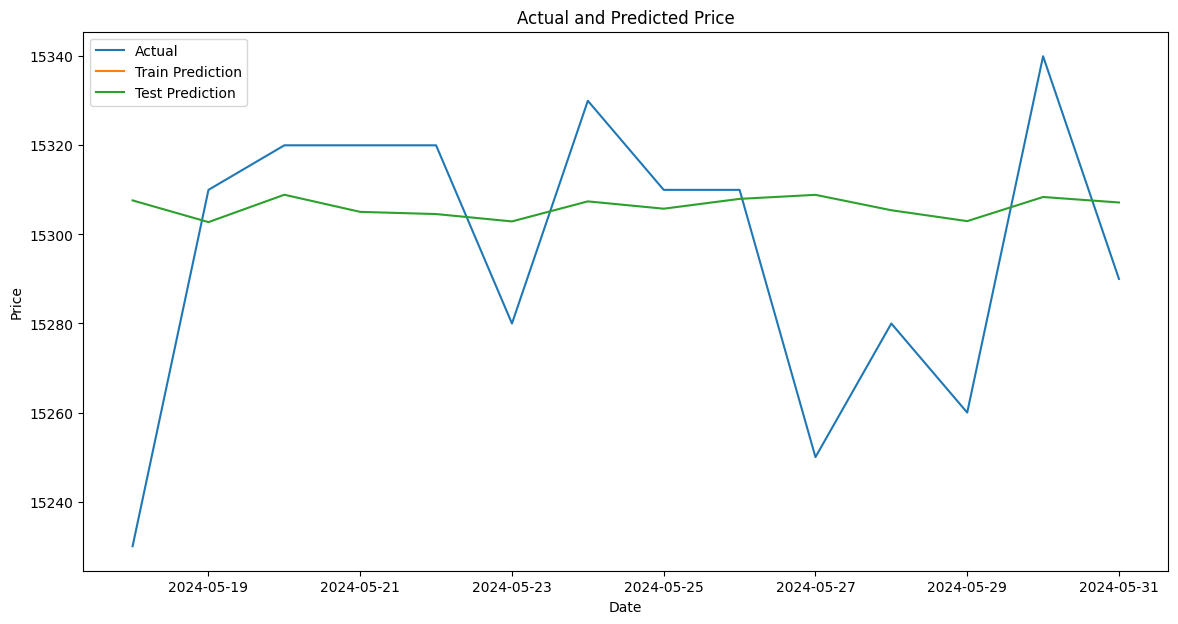

In [ ]:
plt.figure(figsize=(14, 7))
subset_data = inv_boxcox(result_sm2.loc['2024-05-18':], lmd)
sns.lineplot(data=subset_data, x=subset_data.index, y='beras_premium',label='Actual')
sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred',label='Train Prediction')
sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred',label='Test Prediction')

plt.title('Actual and Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
print(f"Train Error : {arima_error(inv_boxcox(train_pm['beras_premium'], lmd)[1:], inv_boxcox(sm2_pred2, lmd)[1:])}")
print(f"Test Error : {arima_error(inv_boxcox(test_pm['beras_premium'], lmd), inv_boxcox(sm2_pred, lmd))}")

Train Error : {'MAE': 30.727916195765797, 'MAPE': 0.22045907494306857}
Test Error : {'MAE': 25.296695067278183, 'MAPE': 0.16559346995547386}


In [ ]:
import os

os.makedirs('model_final_forecasting', exist_ok=True)
os.makedirs('model_final_forecasting/arima', exist_ok=True)
os.makedirs('model_final_forecasting/hybrid', exist_ok=True)

In [ ]:
import joblib

In [ ]:
#Export Model


joblib.dump(model_sm2_fit, 'model_final_forecasting/arima/sarima_model_tr.pkl')

['model_final_forecasting/arima/sarima_model_tr.pkl']

##LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
df_scaled = sc.fit_transform(df_premium)

In [ ]:
joblib.dump(sc, 'scaler_lstm.pkl')

['scaler_lstm.pkl']

<Axes: title={'center': 'Distribution after MinMax Scaling'}, xlabel='beras_premium', ylabel='Density'>

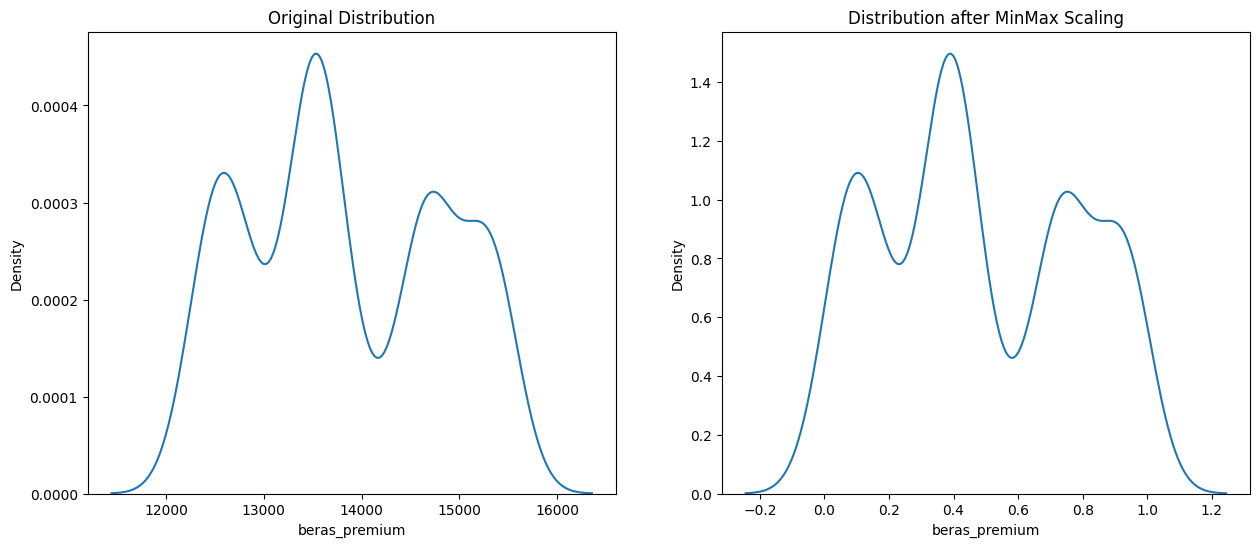

In [ ]:
fig, (ax0,ax1) = plt.subplots(ncols=2, figsize = (15,6))
ax0.set_title('Original Distribution')
ax1.set_title('Distribution after MinMax Scaling')
sns.kdeplot(df_premium['beras_premium'], ax = ax0)
sns.kdeplot(pd.DataFrame(df_scaled, columns=['beras_premium'])['beras_premium'], ax=ax1)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import Input
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [ ]:
def make_data_lstm(df, window_size):
  x = []
  y = []
  for i in range(window_size, len(df)):
    x.append(df[i-window_size:i,0])
    y.append(df[i,0])
  return np.array(x), np.array(y)

In [ ]:
window = 5
x, y = make_data_lstm(df_scaled, window)
print(x.shape)
print(y.shape)

(682, 5)
(682,)


In [ ]:
# x_train = x[:math.floor(len(df_premium)*0.8)]
# y_train = y[:math.floor(len(df_premium)*0.8)]
# x_test = x[math.floor(len(df_premium)*0.8):]
# y_test = y[math.floor(len(df_premium)*0.8):]

x_train = x[:-14]
y_train = y[:-14]
x_test = x[-14:]
y_test = y[-14:]

In [ ]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

In [ ]:
x_train.shape

(668, 5, 1)

### Hyperparameter Tuning

In [ ]:
# !pip install keras-tuner

In [ ]:
from keras_tuner.tuners import RandomSearch

In [ ]:
def build_model(hp):
  model = Sequential()
  model.add(Input(shape=(x_train.shape[1], 1)))
  hp_units1 = hp.Choice('units1', values = [16, 32, 64])
  model.add(LSTM(units = hp_units1, return_sequences=True))
  hp_dropout1 = hp.Float('dropout1', min_value=0.1, max_value=0.4, step=0.1)
  model.add(Dropout(hp_dropout1))

  hp_units2 = hp.Choice('units2', values = [16, 32, 64])
  model.add(LSTM(units = hp_units2))
  hp_dropout2 = hp.Float('dropout2', min_value=0.1, max_value=0.4, step=0.1)
  model.add(Dropout(hp_dropout2))

  model.add(Dense(units = 1))

  hp_learning_rate = hp.Choice('learning_rate', values=[0.005, 0.0005])
  model.compile(optimizer = keras.optimizers.Adam(learning_rate = hp_learning_rate),
                loss = 'mse', metrics = ['mae', 'mape'])

  return model

In [ ]:
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 30,
    executions_per_trial=2,
    directory='/content/drive/My Drive/Tugas Akhir/hasil_tuner_lstm/lstm',
    project_name='lstm_tuning'
)

Reloading Tuner from /content/drive/My Drive/Tugas Akhir/hasil_tuner_lstm/lstm/lstm_tuning/tuner0.json


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  mode = 'min', patience = 20,
                                                  restore_best_weights=True)

tuner.search(x_train, y_train,
             epochs=100,
             validation_split = 0.2,
             batch_size=32,
             callbacks=[early_stopping])

In [ ]:
# import os
# source_dir = 'my_dir'

# target_dir = '/content/drive/My Drive/hasil_tuner_lstm2/lstm_pm
# shutil.copytree(source_dir, target_dir)

In [ ]:
best_param = tuner.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

units1: 64
dropout1: 0.2
units2: 32
dropout2: 0.4
learning_rate: 0.005


In [ ]:
# #Build model
# def make_model(x_train, y_train, num_epoch, best_param):
#   if num_epoch < 1000:
#     num_patience = 20
#   else:
#     num_patience = 400

#   keras.backend.clear_session()
#   tf.random.set_seed(42)
#   # np.random.seed(1)

#   model = Sequential()
#   model.add(Input(shape=(x_train.shape[1], 1)))

#   model.add(LSTM(units = best_param.get('units1'), return_sequences=True))
#   model.add(Dropout(best_param.get('dropout1')))

#   model.add(LSTM(units = best_param.get('units2')))
#   model.add(Dropout(best_param.get('dropout1')))

#   model.add(Dense(units = 1))

#   opt = keras.optimizers.Adam(learning_rate = 0.005)
#   model.compile(optimizer = opt, loss = 'mse', metrics = ['mae', 'mape'])

#   early_stopping = EarlyStopping(monitor = 'loss', mode = 'min',
#                                  patience = num_patience, restore_best_weights=True)

#   hist = model.fit(x_train, y_train, epochs = num_epoch, batch_size = 32,
#                    callbacks = [early_stopping],
#                   #  validation_data=(x_test, y_test),
#                    verbose = 0)

#   return model, hist

In [ ]:
tf.random.set_seed(42)

In [ ]:
keras.backend.clear_session()
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  mode = 'min', patience = 20,
                                                  restore_best_weights=True)

lr = best_param.get('learning_rate')
model_clone = clone_model(best_models)
model_clone.compile(optimizer = keras.optimizers.Adam(learning_rate = lr),
                           loss = 'mse', metrics = ['mae', 'mape'])

hist = model_clone.fit(x_train, y_train,
                       epochs=100,
                       validation_split = 0.2,
                       batch_size=32,
                       callbacks=[early_stopping],
                       verbose=0)

NameError: name 'best_models' is not defined

In [ ]:
model_clone.summary()

NameError: name 'model_clone' is not defined

In [ ]:
model_clone.save('lstm_model_tr_recursive.keras')

In [ ]:
# cloned_model = clone_model(best_models)

In [ ]:
# cloned_model.summary()

In [ ]:
# for layer in cloned_model.layers:
#     if hasattr(layer, 'dropout'):
#         print(f"Dropout rate for {layer}: {layer.dropout}")
#     elif isinstance(layer, Dropout):
#         print(f"Dropout rate for {layer}: {layer.rate}")

In [ ]:
plt.plot(hist.history['loss'])
plt.show()

NameError: name 'hist' is not defined

In [ ]:
train_pred = model_clone.predict(x_train)
train_pred = sc.inverse_transform(train_pred)
y_train_actual = sc.inverse_transform(y_train.reshape(-1,1))

In [ ]:
def lstm_error(actual, pred):
  mape = keras.metrics.MeanAbsolutePercentageError()
  mae = keras.metrics.MeanAbsoluteError()

  mape.update_state(actual, pred)
  mae.update_state(actual, pred)

  return({'MAE' : mae.result().numpy(),
          'MAPE' : mape.result().numpy()})

In [ ]:
train_errors = lstm_error(y_train_actual, train_pred)
print(f'Train Errors : {train_errors}')

NameError: name 'y_train_actual' is not defined

In [ ]:
def plot_result_lstm (split_name, actual, pred):
  plt.figure(figsize=(14, 7))
  x_range = range(1, len(actual)+1)
  plt.plot(x_range, actual, color ='red', label = 'Aktual')
  plt.plot(x_range, pred, color = 'blue', label = 'Prediksi')
  plt.title(f'Aktual vs Prediksi ({split_name})')
  plt.xlabel('Hari')
  plt.ylabel('Harga')
  plt.legend(['Aktual', 'Prediksi'], loc = 'upper left')
  plt.show()

In [ ]:
plot_result_lstm('Train', y_train_actual, train_pred)

In [ ]:
test_pred = model_clone.predict(x_test)
test_pred = sc.inverse_transform(test_pred)
y_test_actual = sc.inverse_transform(y_test.reshape(-1,1))

In [ ]:
test_errors = lstm_error(y_test_actual, test_pred)
print(f'Test Errors : {test_errors}')

In [ ]:
plot_result_lstm('Test', y_test_actual, test_pred)

In [ ]:
# demonstrate prediction for next 10 days
def lstm_forecast(steps):
  x_input = df_scaled[:-(steps)][-(window):]
  temp_input =  x_input
  output=[]
  i=0
  while(i<steps):
    x_input = temp_input
    x_input = x_input.reshape((1, window, 1))
    # print("{} day input {}".format(i,x_input))
    pred = model_clone.predict(x_input, verbose=0)
    # print("{} day output {}".format(i,pred))
    temp_input = temp_input[1:]
    temp_input = np.append(temp_input, pred[0][0])
    output = np.append(output, pred[0][0])
    i=i+1
  pred = sc.inverse_transform(output.reshape(-1,1))
  return pred, steps

In [ ]:
pred, steps = lstm_forecast(steps = 14)

In [ ]:
lstm_recursive = df_premium[-(steps):].copy()
lstm_recursive['Prediction'] = pred

In [ ]:
lstm_recursive.head()

In [ ]:
recursive_errors = lstm_error(lstm_recursive['beras_premium'], lstm_recursive['Prediction'])
print(f'Test Errors : {recursive_errors}')

In [ ]:
plot_result_lstm('Forecast', lstm_recursive['beras_premium'], lstm_recursive['Prediction'])

### Direct Strategy


In [ ]:
def make_data_direct(data, window_size, n_steps):
  x1, y1 = [], []
  for i in range(len(data) - window_size - n_steps + 1):
    x1.append(data[i:(i + window_size)])
    y1.append(data[(i + window_size):(i + window_size + n_steps)])

  return np.array(x1), np.array(y1)

In [ ]:
window_size = 5
n_steps = 14
x1,y1 = make_data_direct(df_scaled, window_size, n_steps)

In [ ]:
print(x1.shape)
print(y1.shape)

(669, 5, 1)
(669, 14, 1)


In [ ]:
x_train1 = x1[:-n_steps]
y_train1 = y1[:-n_steps]
x_test1 = x1[-n_steps:]
y_test1 = y1[-n_steps:]

In [ ]:
def fitting(model, x, y, epoch, val_split, isHybrid = False):
  keras.backend.clear_session()
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  mode = 'min', patience = 20,
                                                  restore_best_weights=True)

  callback = [early_stopping]
  if isHybrid == True:
    callback = None

  hist = model.fit(x, y,
                   epochs = epoch,
                   validation_split = val_split,
                   batch_size=32,
                   callbacks=callback,
                   verbose=0)

  return model, hist

In [ ]:
# build all models
lr = best_param.get('learning_rate')
models = []
rows =  math.ceil(n_steps/2)
cols = 2
step_temp = 0
fig,axs = plt.subplots(rows, cols, figsize=(15, 30))
for i in range(rows):
  for j in range(cols):
    model_clone1 = clone_model(best_models)
    model_clone1.compile(optimizer = keras.optimizers.Adam(learning_rate = lr),
                           loss = 'mse', metrics = ['mae', 'mape'])
    regressor1, hist = fitting(model_clone1, x_train1, y_train1[:, (step_temp)], 100, isHybrid = False)
    models.append(regressor1)
    if step_temp < n_steps:
      ax = axs[i,j]
      ax.plot(hist.history['loss'], label=f'Model Loss ({step_temp+1})')
      ax.legend()
      step_temp += 1
    else:
      fig.delaxes(axs[i,j])
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
models = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/model_akhir/premium/lstm/lstm_model_tr_{i}.keras')
  models.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()

In [ ]:
# def direct_prediction(model, x):
#   return model.predict(x).flatten()

In [ ]:
def direct_lstm_pred(models, x, scaler, n_steps):
  # predict
  direct_pred = np.zeros((x.shape[0], n_steps))
  for i, regs in enumerate(models):
    direct_pred[:, i] = regs.predict(x).flatten()
  direct_pred = scaler.inverse_transform(direct_pred)

  return direct_pred

In [ ]:
#calculating error
def lstm_error_direct(actual, pred, scaler, n_steps, hybrid: bool):
  if not isinstance(hybrid, bool):
    raise ValueError("Expected Boolean (True or False)")

  if (hybrid==False):
    y_actual = scaler.inverse_transform(actual.reshape(actual.shape[0], actual.shape[1]))
  elif (hybrid==True):
    y_actual = actual.reshape(actual.shape[0], actual.shape[1])
    pred = pred.to_numpy()

  erors_data = []
  for i in range(n_steps):
    erors_temp = lstm_error(y_actual[:, i], pred[:, i])
    erors_dict = {'Step' : i+1}
    erors_dict.update(erors_temp)
    erors_data.append(erors_dict)
  df_direct_err = pd.DataFrame(erors_data)

  return df_direct_err

In [ ]:
def lstm_direct_plot(actual, pred, scaler, n_steps, hybrid: bool):
  if not isinstance(hybrid, bool):
    raise ValueError("Expected Boolean (True or False)")

  if (hybrid==False):
    y_actual = scaler.inverse_transform(actual.reshape(actual.shape[0], actual.shape[1]))
  elif (hybrid==True):
    y_actual = actual.reshape(actual.shape[0], actual.shape[1])
    pred = pred.to_numpy()

  rows =  math.ceil(n_steps/2)
  cols = 2
  step_temp = 0
  #plotting
  fig,axs = plt.subplots(rows, cols, figsize=(16, 16))
  for i in range(rows):
    for j in range(cols):
      if step_temp < n_steps:
        ax = axs[i,j]
        ax.plot(y_actual[:, step_temp], label=f'Actual Step {step_temp+1}')
        ax.plot(pred[:, step_temp], label=f'Predicted Step {step_temp+1}')
        ax.legend()
        step_temp += 1
      else:
        fig.delaxes(axs[i,j])

  plt.tight_layout()
  plt.show()

In [ ]:
pred_train = direct_lstm_pred(models, x_train1, sc, n_steps)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [ ]:
pred_train[:5]

array([[12544.33533102, 12332.86011964, 12343.56983602, 12293.10283065,
        12308.65553021, 12325.66706985, 12297.49759436, 12380.6822367 ,
        12381.08730614, 12380.62732182, 12383.72543305, 12314.8952961 ,
        12323.79649729, 12314.71723765],
       [12536.38124242, 12323.8904193 , 12333.90666172, 12286.31694019,
        12299.52355623, 12315.80653638, 12288.43131661, 12370.85705921,
        12372.53804207, 12370.8685413 , 12374.65345114, 12304.54425365,
        12313.34548444, 12304.00117785],
       [12544.18662935, 12332.94878006, 12342.92445406, 12300.07892549,
        12309.67677236, 12325.10260344, 12298.56574833, 12380.551631  ,
        12382.7601999 , 12380.19116223, 12384.4307825 , 12314.75033164,
        12323.82688671, 12314.04104829],
       [12548.5262692 , 12339.20467496, 12347.34178856, 12311.39549613,
        12317.18620658, 12330.11545762, 12306.70647621, 12386.02895662,
        12390.94646275, 12385.58034375, 12391.76869839, 12321.04300857,
        12329

In [ ]:
train_len = math.floor(len(y_train1)*0.80)

In [ ]:
error_train = lstm_error_direct(y_train1[:train_len], pred_train[:train_len], sc, n_steps, hybrid=False)
error_train

,Step,MAE,MAPE
0,1,114.970909,0.882788
1,2,45.826462,0.339974
2,3,54.618832,0.405684
3,4,48.717457,0.359776
4,5,60.004337,0.442827
5,6,61.377258,0.454325
6,7,71.635101,0.527155
7,8,92.372589,0.686481
8,9,90.409927,0.670452
9,10,94.798164,0.702142


In [ ]:
error_train = lstm_error_direct(y_train1[train_len:], pred_train[train_len:], sc, n_steps, hybrid=False)
error_train

,Step,MAE,MAPE
0,1,49.329128,0.325442
1,2,53.281078,0.351830
2,3,60.737400,0.401017
3,4,64.851151,0.428020
4,5,73.248741,0.483351
5,6,78.544205,0.517762
6,7,86.167168,0.568748
7,8,88.855240,0.585877
8,9,94.812645,0.624908
9,10,100.234711,0.660300


In [ ]:
pred_test = direct_lstm_pred(models, x_test1, sc, n_steps)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [ ]:
error_test = lstm_error_direct(y_test1, pred_test, sc, n_steps, hybrid=False)
error_test

,Step,MAE,MAPE
0,1,26.897463,0.176064
1,2,21.974970,0.144029
2,3,23.857241,0.156295
3,4,22.509333,0.147466
4,5,17.942480,0.117563
5,6,22.235136,0.145496
6,7,22.245142,0.145734
7,8,23.122662,0.151278
8,9,18.229267,0.119418
9,10,23.268259,0.152405


In [ ]:
pred_test[-5:]

array([[15293.92707348, 15316.19298458, 15314.40128684, 15316.71737432,
        15319.19455528, 15305.00751138, 15331.49194717, 15309.39598083,
        15324.06669855, 15319.47209239, 15345.50471902, 15329.5753479 ,
        15337.11172938, 15335.17290354],
       [15286.26343012, 15308.77245665, 15306.98292255, 15306.58441782,
        15311.53936982, 15297.70323038, 15324.24510121, 15302.33304501,
        15316.32319689, 15312.72504926, 15337.99548149, 15322.58754969,
        15329.8363626 , 15328.54269743],
       [15284.45580006, 15306.21384382, 15305.60113788, 15302.70165205,
        15308.69515538, 15295.92726827, 15321.1556077 , 15300.57517886,
        15313.16190958, 15310.8961761 , 15335.32573581, 15320.45812607,
        15328.18923593, 15326.45379305],
       [15280.4168582 , 15302.26223469, 15301.7647922 , 15301.39598846,
        15305.42096496, 15292.19084382, 15317.77972579, 15297.09445834,
        15310.18118858, 15307.11293817, 15331.99135661, 15317.03326702,
        15324

In [ ]:
direct_pred_val = pred_test[pred_test.shape[0]-1:]
direct_pred_val = direct_pred_val.transpose()

In [ ]:
direct_val_error = lstm_error(df_premium[-14:], direct_pred_val)
print(f'Test Errors : {direct_val_error}')

Test Errors : {'MAE': 25.513735, 'MAPE': 0.16698334}


In [ ]:
print(f"Test Error : {arima_error(df_premium[-14:], direct_pred_val)}")

Test Error : {'MAE': 25.51373549870082, 'MAPE': 0.1669833277348258}


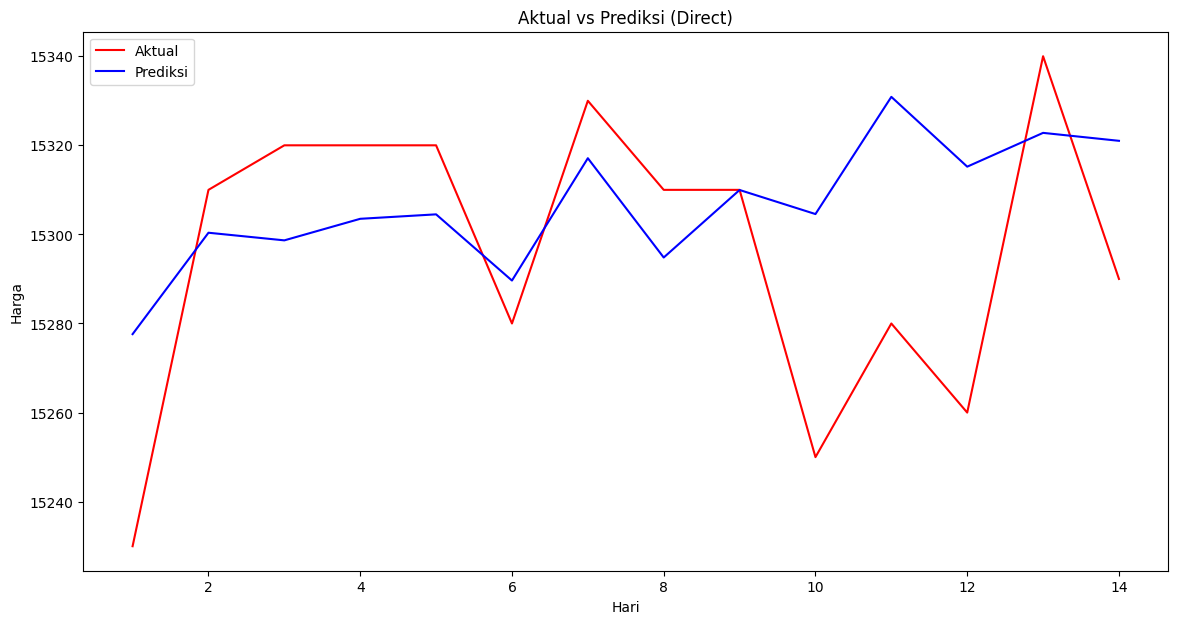

In [ ]:
plot_result_lstm('Direct', df_premium[-14:].values, direct_pred_val)

In [ ]:
for i, model in enumerate(models):
  model.save(f'lstm_model_tr_{i}.keras')

## Hybrid Model


In [ ]:
window_size = 5
steps = 14

In [ ]:
sc2 = MinMaxScaler(feature_range = (0,1))

def residualForLstm(actual, pred, scaller):
  temp = actual.copy()
  temp['pred'] = pred
  temp['residual'] = temp.iloc[:, 0] - temp.iloc[:, 1]
  residual = pd.DataFrame(temp['residual'][1:], columns=['residual'])
  resid_scaled = scaller.fit_transform(residual)

  return resid_scaled

In [ ]:
joblib.dump(sc2, 'model_final_forecasting/hybrid/scaler_hybrid.pkl')

['model_final_forecasting/hybrid/scaler_hybrid.pkl']

### Get Best Parameters for Modelling Residual

In [ ]:
best_order = model_auto.order
best_seasonal = model_auto.seasonal_order

sarima_model = SARIMAX(train_pm, order = best_order, seasonal_order = best_seasonal).fit()
sarima_pred1 = sarima_model.predict(start = train_pm.index[0], end = train_pm.index[-1])
sarima_pred1 = sarima_pred1.to_frame(name='pred')
sarima_pred1 = inv_boxcox(sarima_pred1, lmd)
resid_sc = residualForLstm(inv_boxcox(train_pm, lmd), sarima_pred1, sc2)
x_resid, y_resid = make_data_direct(resid_sc, window_size, steps)

In [ ]:
import os
import shutil

In [ ]:
# tuner_dir = 'my_dir_hybrid'
# if os.path.exists(tuner_dir):
#     shutil.rmtree(tuner_dir)

In [ ]:
tuner2 = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 25,
    executions_per_trial=1,
    directory='/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-pm-hybrid',
    project_name='lstm_tuning'
)

Reloading Tuner from /content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-pm-hybrid/lstm_tuning/tuner0.json


In [ ]:
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
#                                                   mode = 'min', patience = 200,
#                                                   restore_best_weights=True)

tuner2.search(x_resid, y_resid[:, 0],
              epochs=1000,
              validation_split = 0.2,
              batch_size=32,
              # callbacks=[early_stopping],
              verbose=0)

In [ ]:
best_param = tuner2.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

In [ ]:
os.makedirs('model_final_forecasting/hybrid-70', exist_ok=True)
os.makedirs('model_final_forecasting/hybrid-60', exist_ok=True)

In [ ]:
tuner3 = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 25,
    executions_per_trial=1,
    directory='/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-pm-hybrid-70',
    project_name='lstm_tuning'
)

In [ ]:
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
#                                                   mode = 'min', patience = 200,
#                                                   restore_best_weights=True)

tuner3.search(x_resid, y_resid[:, 0],
              epochs=1000,
              validation_split = 0.3,
              batch_size=32,
              # callbacks=[early_stopping],
              verbose=0)

In [ ]:
best_param2 = tuner3.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

units1: 64
dropout1: 0.30000000000000004
units2: 32
dropout2: 0.1
learning_rate: 0.005


In [ ]:
# # import os
# source_dir = 'my_dir_hybrid2'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-pm-hybrid-70'

# shutil.copytree(source_dir, target_dir)

'/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-pm-hybrid-70'

In [ ]:
tuner4 = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 25,
    executions_per_trial=1,
    directory='/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-pm-hybrid-60',
    project_name='lstm_tuning'
)

In [ ]:
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
#                                                   mode = 'min', patience = 200,
#                                                   restore_best_weights=True)

tuner4.search(x_resid, y_resid[:, 0],
              epochs=1000,
              validation_split = 0.4,
              batch_size=32,
              # callbacks=[early_stopping],
              verbose=0)

In [ ]:
best_param3 = tuner4.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

units1: 64
dropout1: 0.30000000000000004
units2: 32
dropout2: 0.1
learning_rate: 0.005


In [ ]:
# # import os
# source_dir = 'my_dir_hybrid3'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-pm-hybrid-60'

# shutil.copytree(source_dir, target_dir)

In [ ]:
# order = model_auto.order
# seasonal_order = model_auto.seasonal_order
# print(f"Best ARIMA order: {best_order}")
# print(f"Best seasonal order: {best_seasonal_order}")

In [ ]:
def hybrid_model_fit(data, num_epoch, best_auto_am, scaller, val_split, tuner_name):
  best_lstm = tuner_name.get_best_models(num_models=1)[0]
  best_hps = tuner_name.get_best_hyperparameters(num_trials=1)[0]
  lr = best_hps.get('learning_rate')
  best_order = best_auto_am.order
  best_seasonal = best_auto_am.seasonal_order

  sarima_model= SARIMAX(data, order = best_order, seasonal_order = best_seasonal).fit()
  sarima_pred = sarima_model.predict(start = data.index[0], end = data.index[-1])
  sarima_pred = sarima_pred.to_frame(name='pred')
  resid_scaled = residualForLstm(inv_boxcox(data, lmd), inv_boxcox(sarima_pred, lmd), scaller)

  x, y = make_data_direct(resid_scaled, window_size, steps)

  lstm_model = []
  rows =  math.ceil(steps/2)
  cols = 2
  step_temp = 0

  fig,axs = plt.subplots(rows, cols, figsize=(15, 30))
  for i in range(rows):
    for j in range(cols):
      cloned_model = clone_model(best_lstm)
      cloned_model.compile(optimizer = keras.optimizers.Adam(learning_rate = lr),
                           loss = 'mse', metrics = ['mae', 'mape'])
      model, hist = fitting(cloned_model, x, y[:, (step_temp)], num_epoch, val_split, isHybrid = True)
      lstm_model.append(model)
      if step_temp < steps:
        ax = axs[i,j]
        ax.plot(hist.history['loss'], label=f'Model Loss ({step_temp+1})')
        ax.legend()
        step_temp += 1
      else:
        fig.delaxes(axs[i,j])
  plt.tight_layout()
  plt.show()

  return sarima_model, lstm_model

In [ ]:
from tensorflow.keras.models import load_model
lstm_model = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2/premium/model_final_forecasting/hybrid/lstm_model_tr_{i}_hybrid.keras')
  lstm_model.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()

In [ ]:
arima_tr = train_pm

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


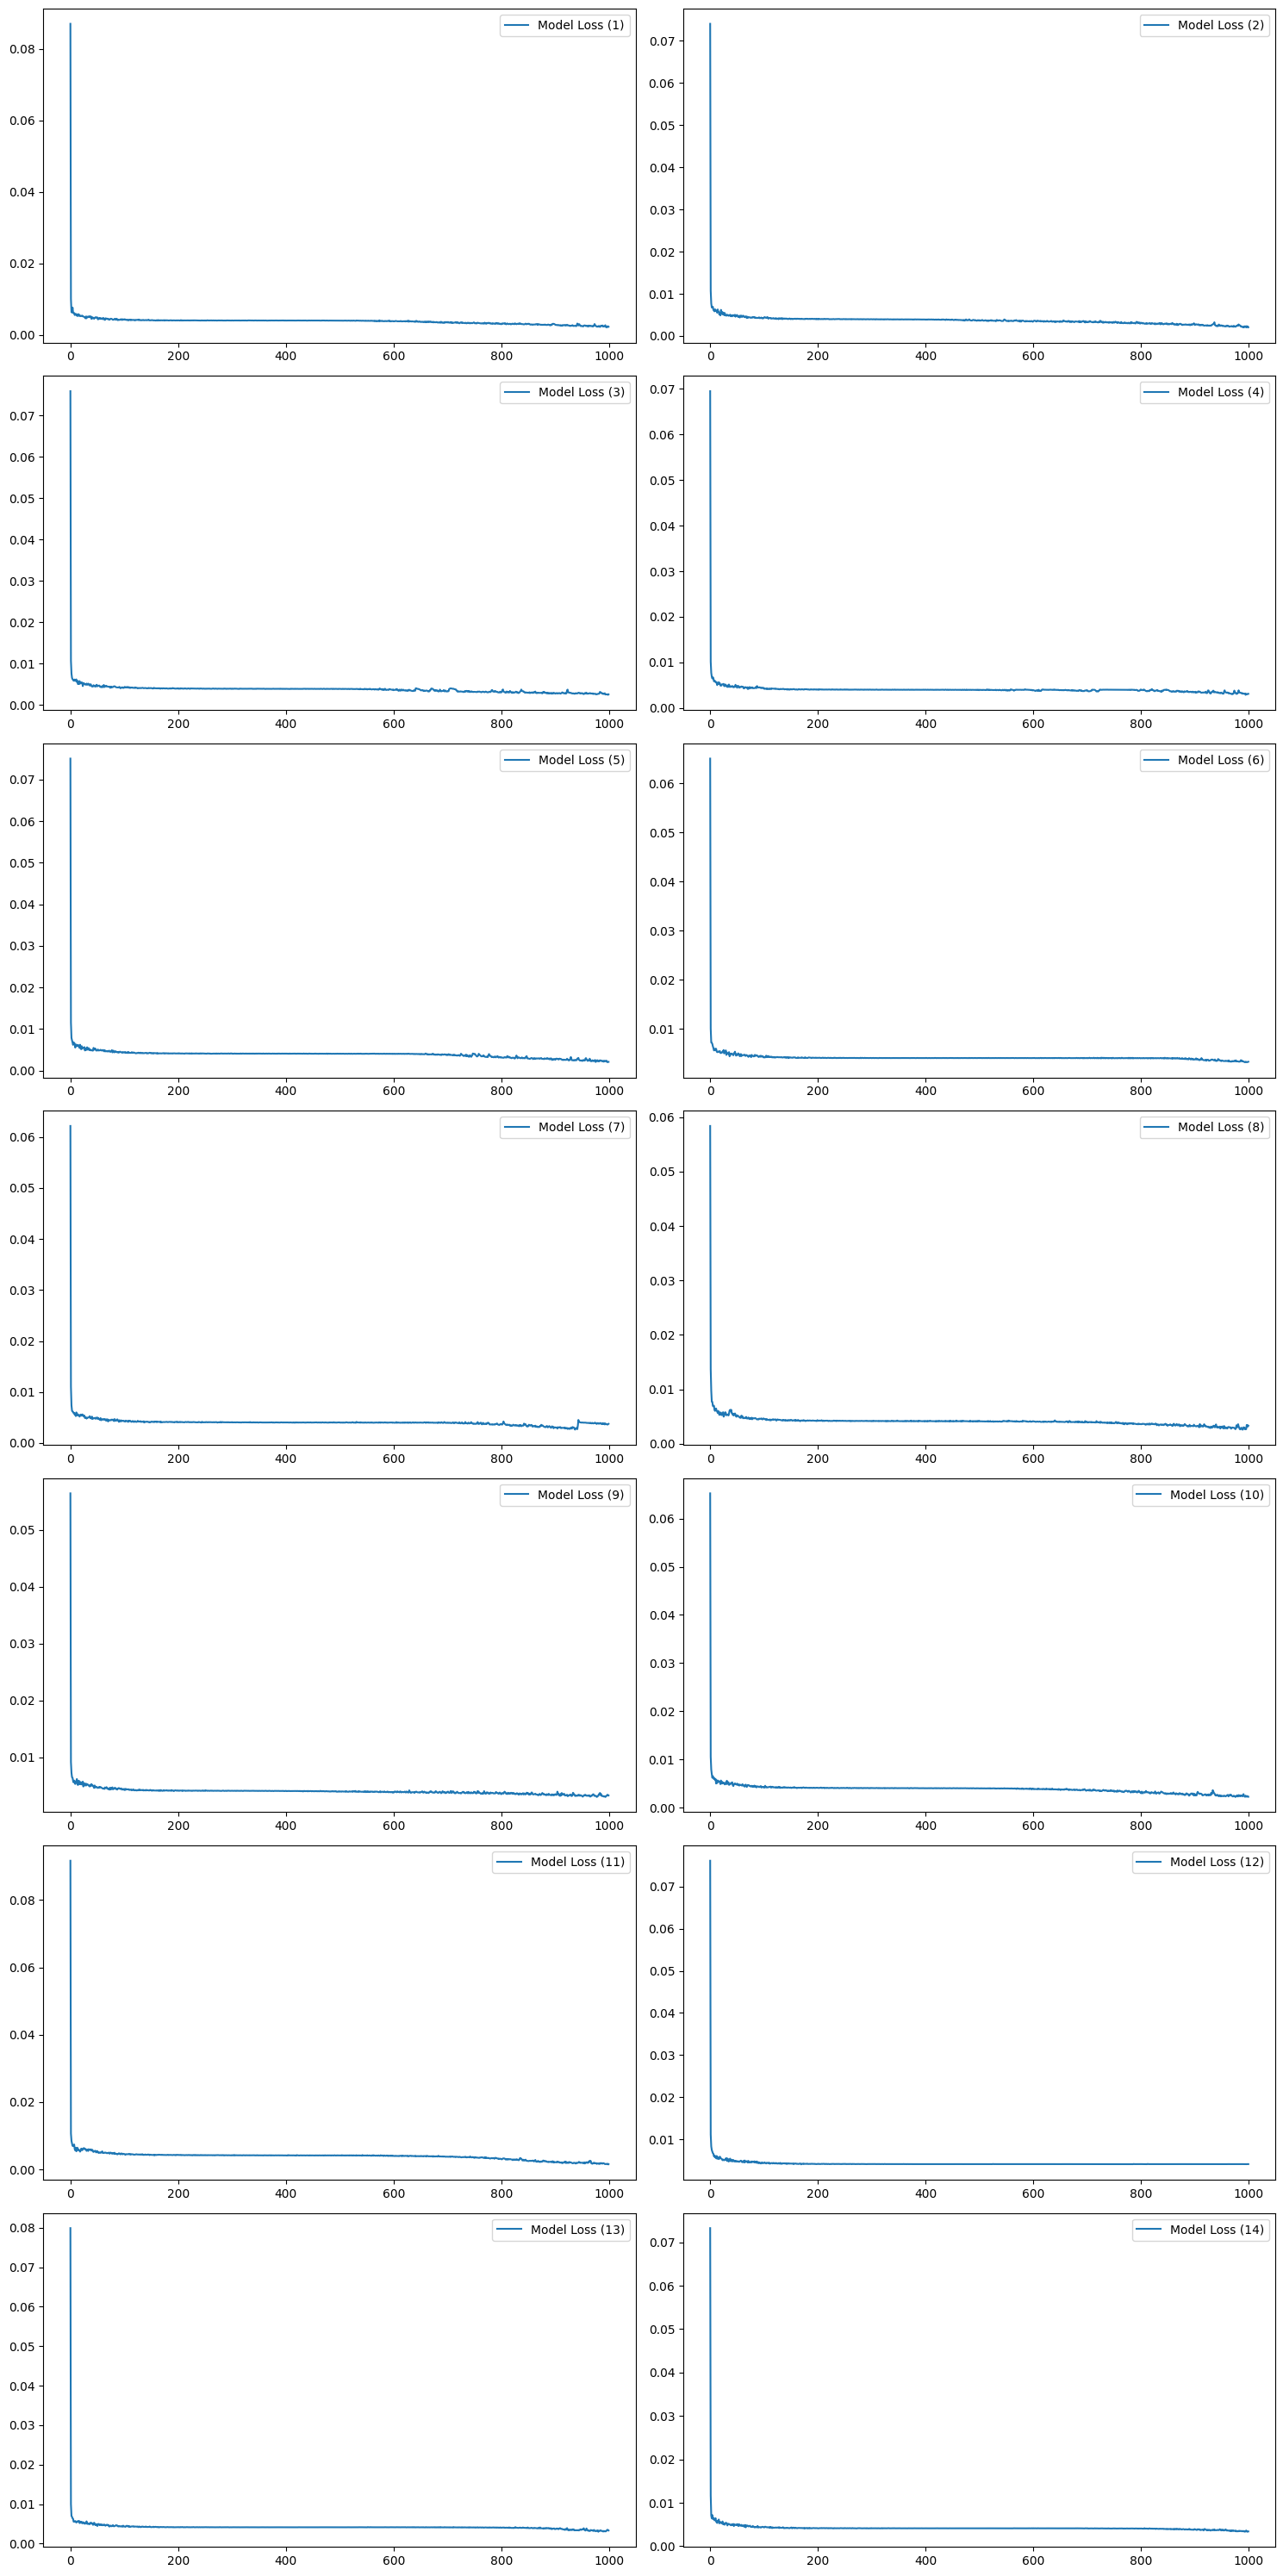

In [ ]:
sarima_model, lstm_model= hybrid_model_fit(arima_tr, 1000, model_auto, sc2, 0.2, tuner2)

In [ ]:
from tensorflow.keras.models import load_model
lstm_model2 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2/premium/model_final_forecasting-60-70/hybrid-70/lstm_model_tr_{i}_hybrid.keras')
  lstm_model2.append(model_tr)

sarima_model2 = joblib.load('/content/drive/MyDrive/Tugas Akhir/final_model2/premium/model_final_forecasting-60-70/hybrid-70/sarima_model_tr_hybrid.pkl')

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


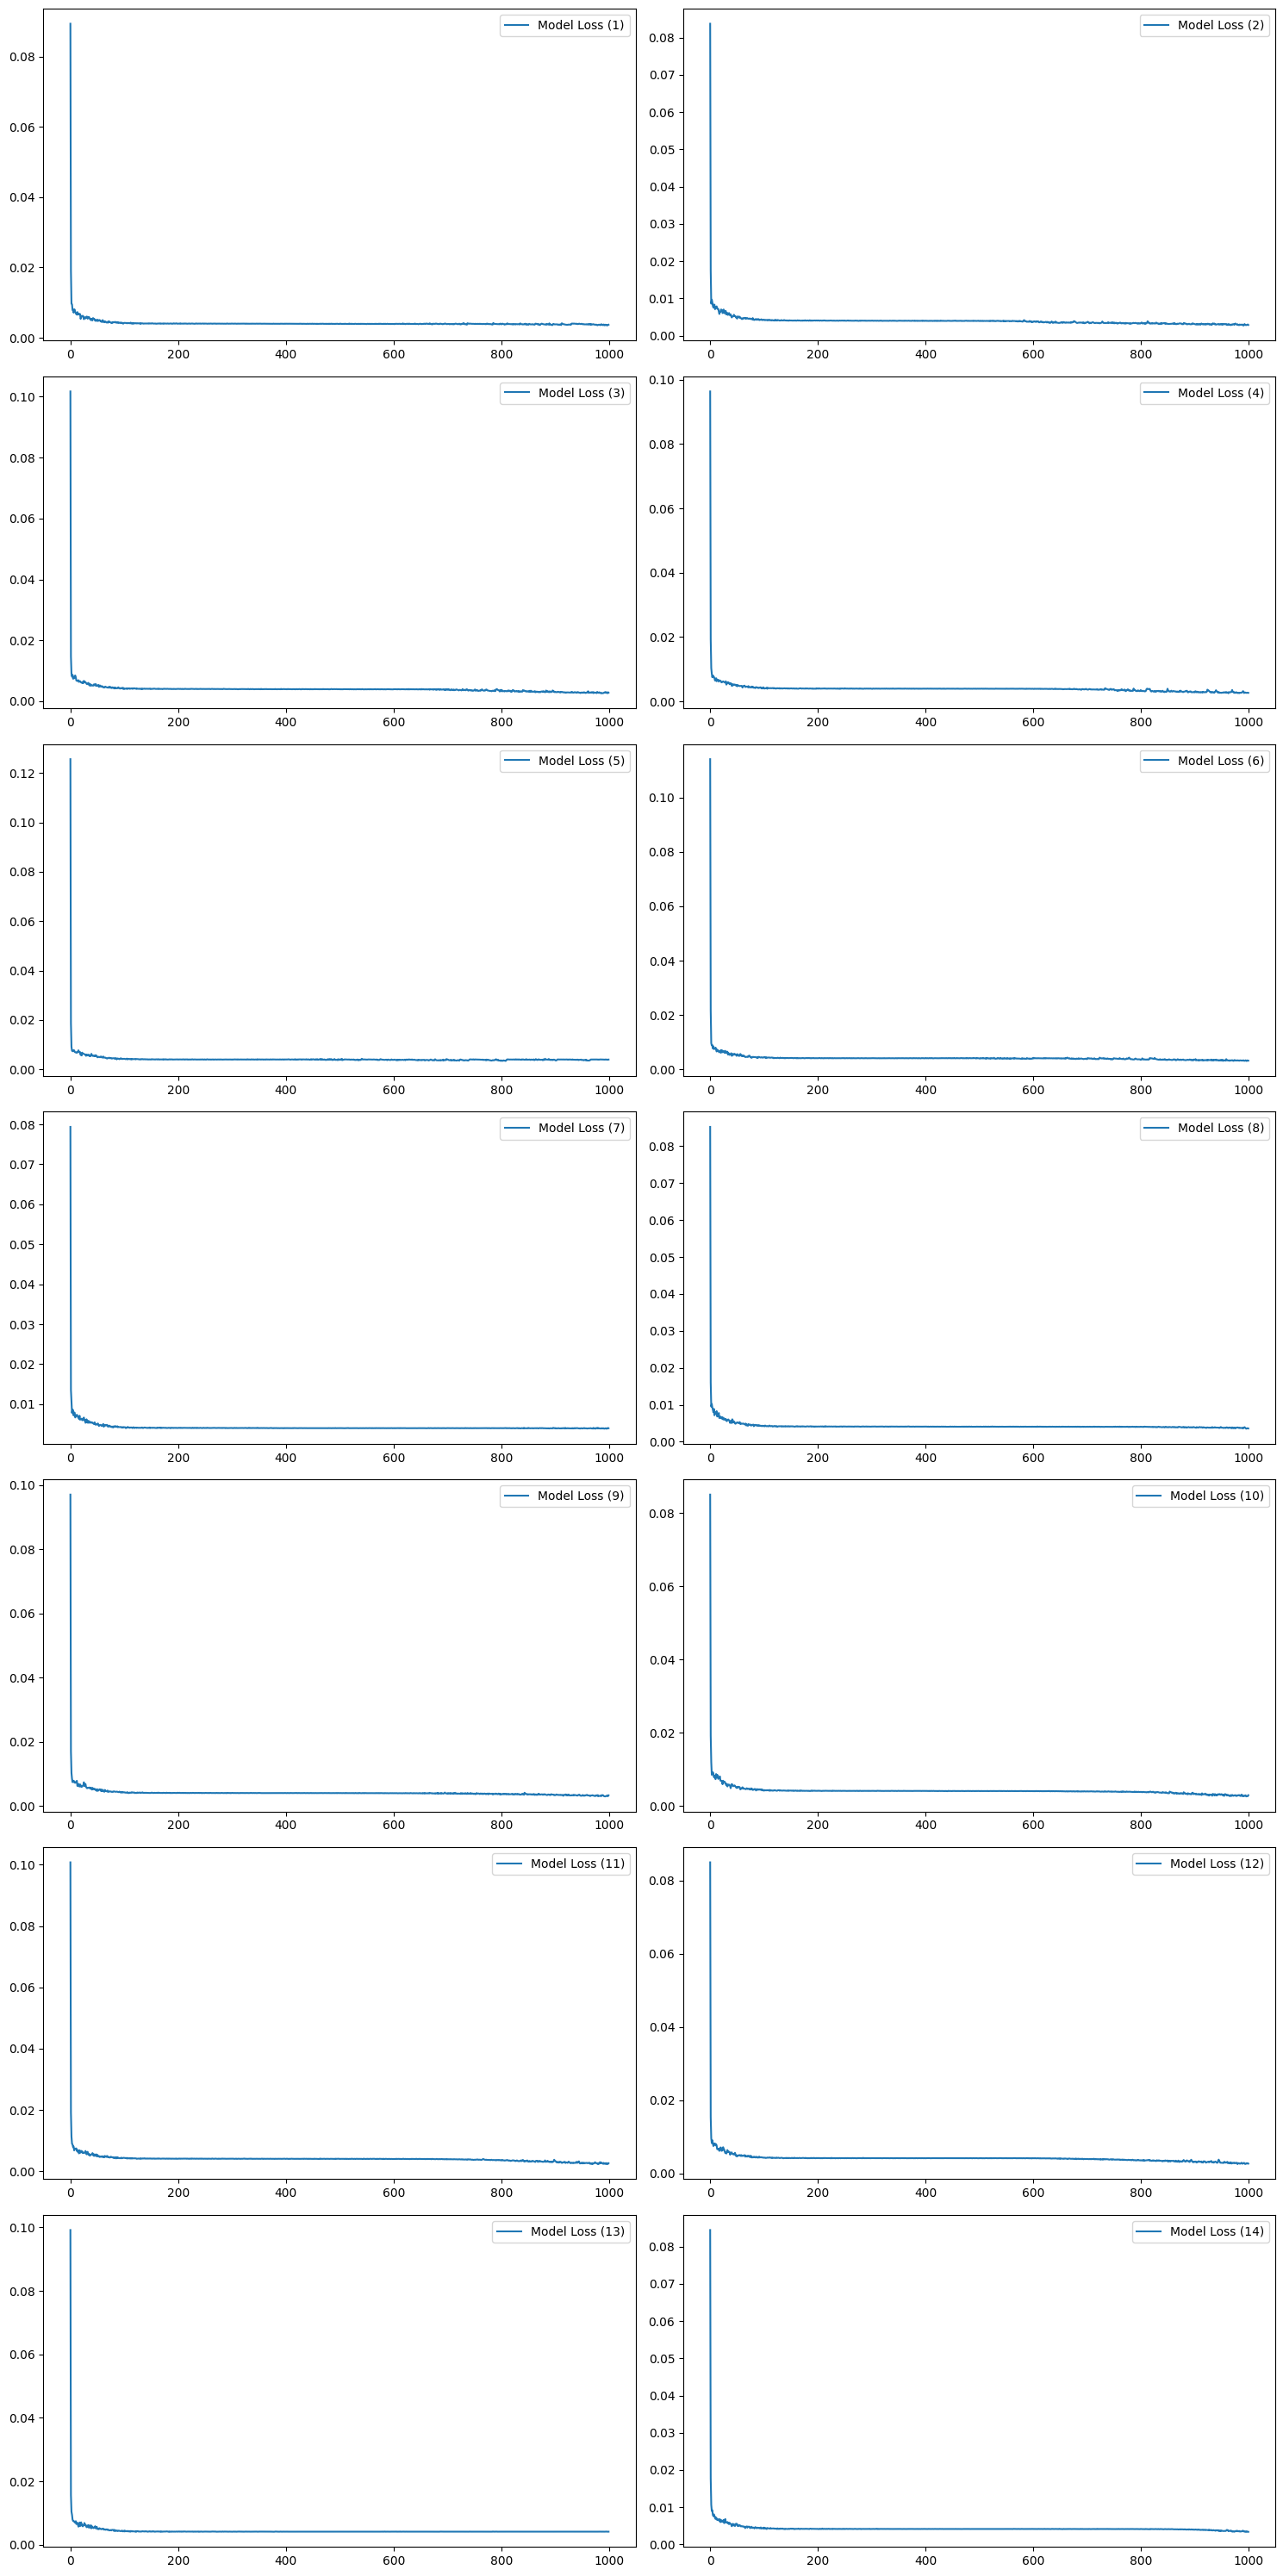

In [ ]:
sarima_model2, lstm_model2= hybrid_model_fit(arima_tr, 1000, model_auto, sc2, 0.3, tuner3)

In [ ]:
#Export Model
joblib.dump(sarima_model2, 'model_final_forecasting/hybrid-70/sarima_model_tr_hybrid.pkl')

['model_final_forecasting/hybrid-70/sarima_model_tr_hybrid.pkl']

In [ ]:
for i, model in enumerate(lstm_model2):
  model.save(f'model_final_forecasting/hybrid-70/lstm_model_tr_{i}_hybrid.keras')

In [ ]:
from tensorflow.keras.models import load_model
lstm_model3 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2/premium/model_final_forecasting-60-70/hybrid-60/lstm_model_tr_{i}_hybrid.keras')
  lstm_model3.append(model_tr)

sarima_model3 = joblib.load('/content/drive/MyDrive/Tugas Akhir/final_model2/premium/model_final_forecasting-60-70/hybrid-60/sarima_model_tr_hybrid.pkl')

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


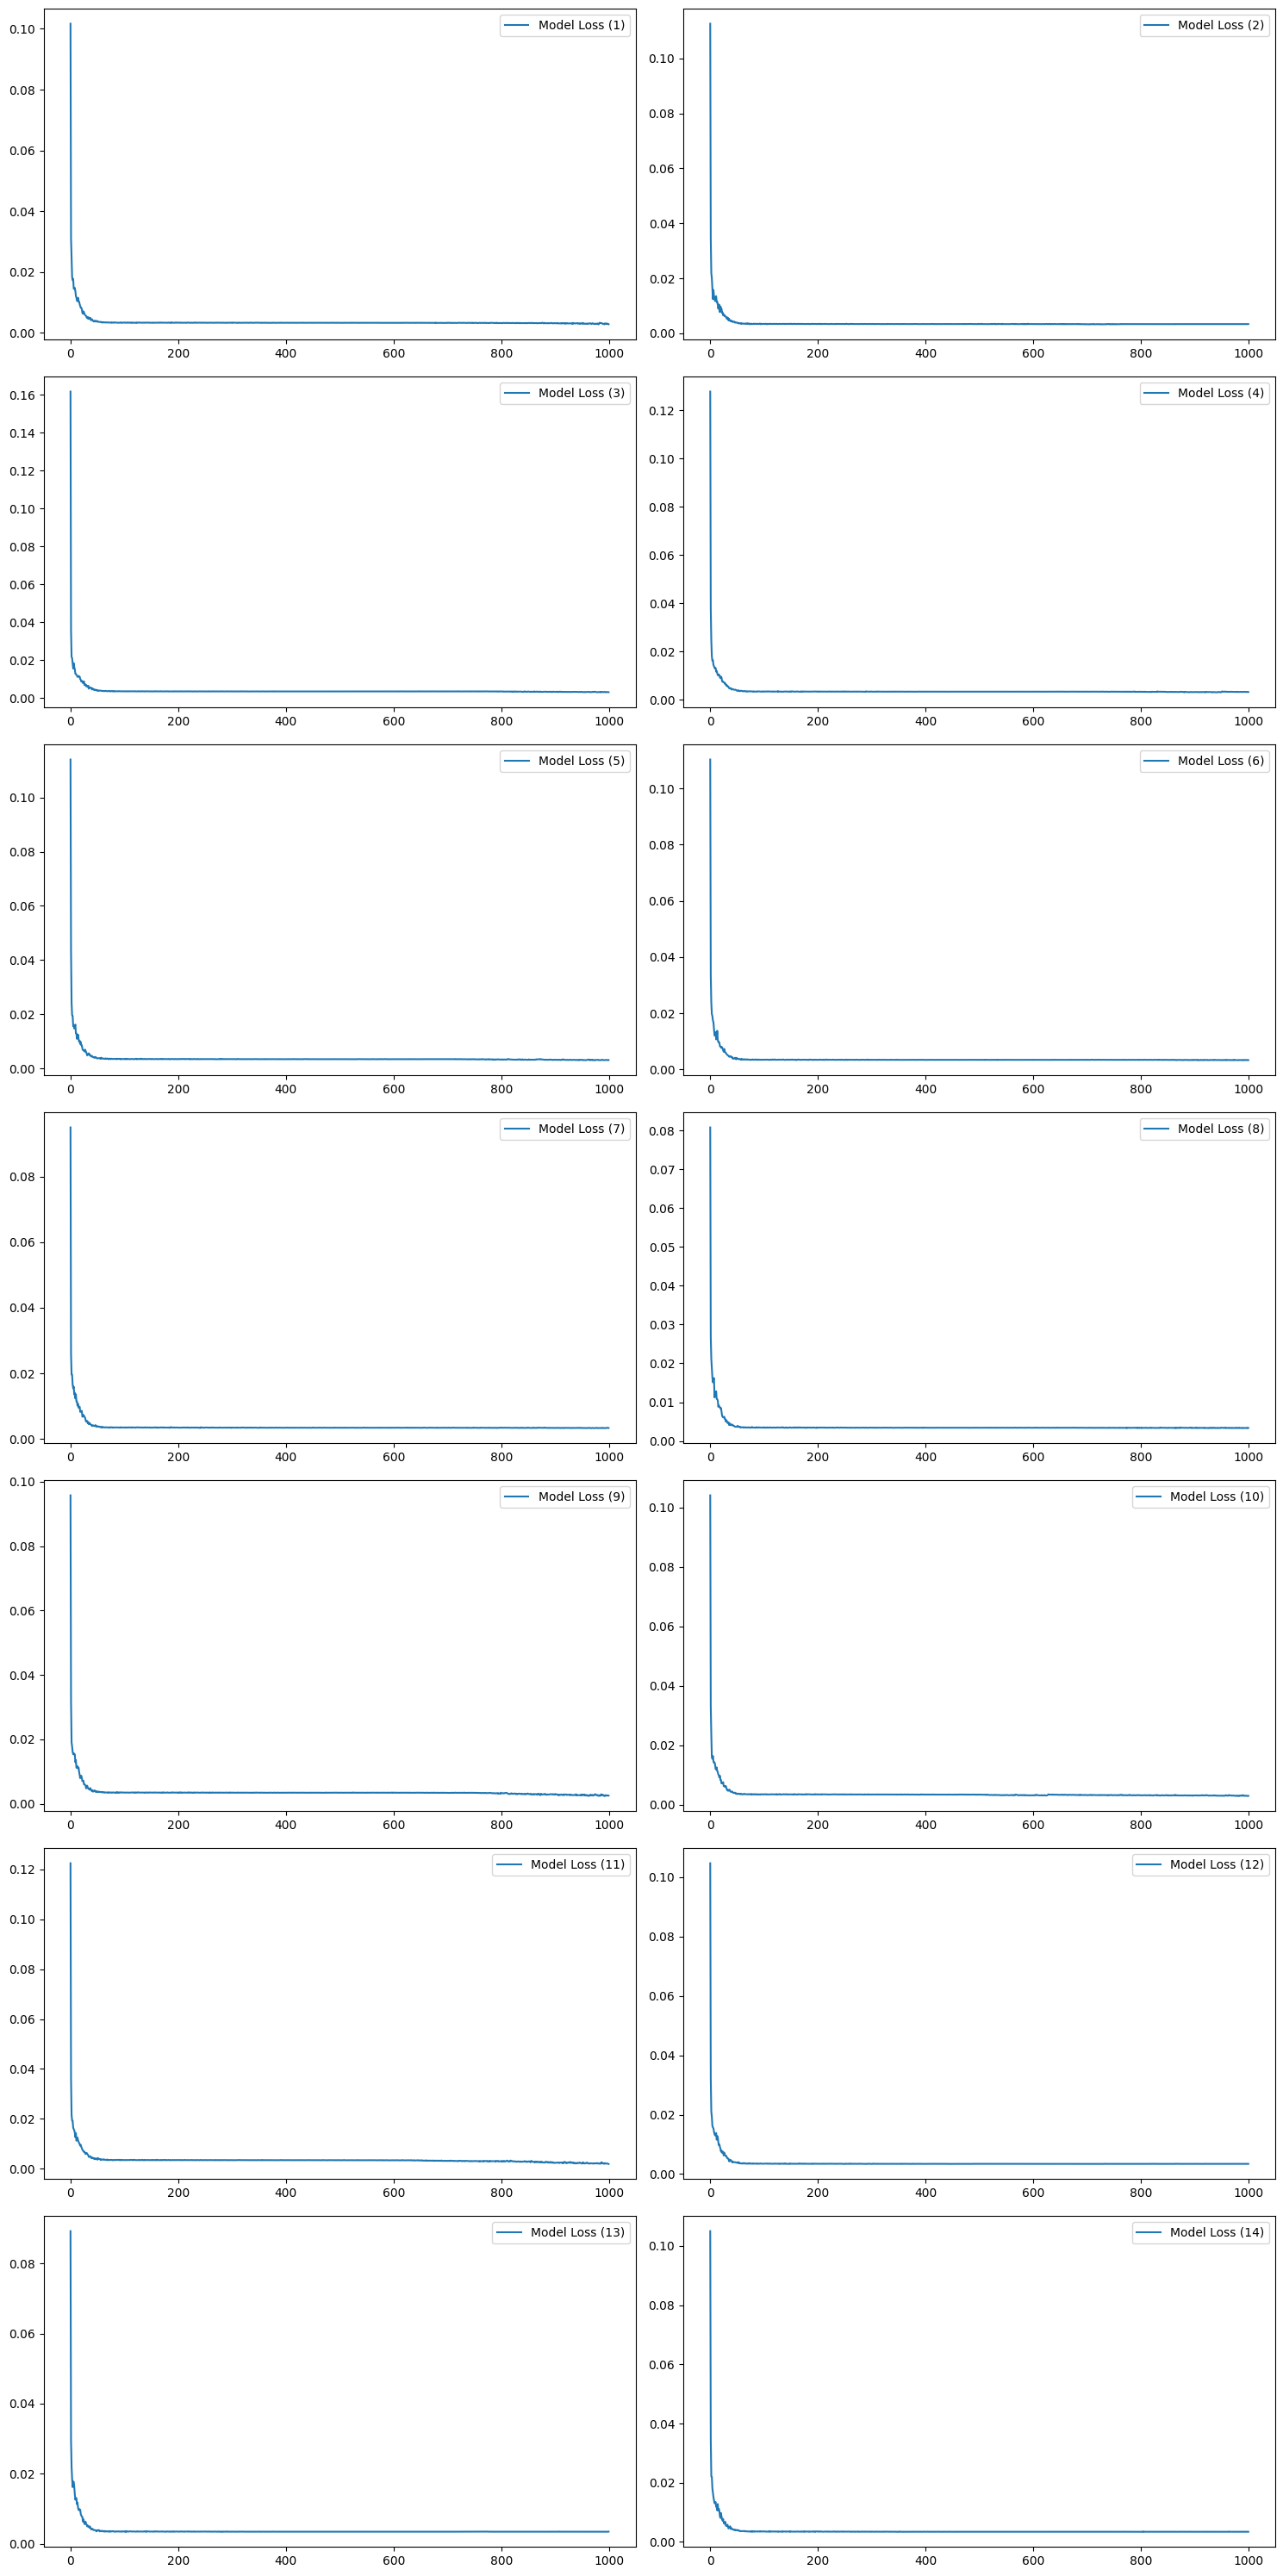

In [ ]:
sarima_model3, lstm_model3= hybrid_model_fit(arima_tr, 1000, model_auto, sc2, 0.4, tuner4)

In [ ]:
#Export Model
joblib.dump(sarima_model3, 'model_final_forecasting/hybrid-60/sarima_model_tr_hybrid.pkl')

['model_final_forecasting/hybrid-60/sarima_model_tr_hybrid.pkl']

In [ ]:
for i, model in enumerate(lstm_model3):
  model.save(f'model_final_forecasting/hybrid-60/lstm_model_tr_{i}_hybrid.keras')

In [ ]:
# # import os
# source_dir = 'model_final_forecasting'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/premium/model_final_forecasting-60-70'

# shutil.copytree(source_dir, target_dir)

'/content/drive/My Drive/Tugas Akhir/final_model2/premium/model_final_forecasting-60-70'

In [ ]:
def hybrid_model_predict(X, scaller, sm_model, lm_model):
  sarima_pred= sm_model.predict(start = X.index[0], end = X.index[-1])
  resid_scaled= residualForLstm(inv_boxcox(X, lmd), inv_boxcox(sarima_pred, lmd), scaller)
  x_am, y_am = make_data_direct(inv_boxcox(sarima_pred[1:], lmd), window_size, steps)
  x, y = make_data_direct(resid_scaled, window_size, steps)
  direct_pred = direct_lstm_pred(lm_model, x, scaller, steps)

  resid_pred = pd.DataFrame(direct_pred)
  sarima_pred2 = pd.DataFrame(y_am)
  final_pred = pd.DataFrame()
  for i in range(steps):
    final_pred[f'step {i+1}'] = sarima_pred2[i] + resid_pred[i]

  return final_pred
  # return sarima_pred2, x, resid_scaled,y, x_am, y_am

In [ ]:
hybrid_pred = hybrid_model_predict(arima_tr, sc2, sarima_model, lstm_model)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [ ]:
hybrid_pred_70 = hybrid_model_predict(arima_tr, sc2, sarima_model2, lstm_model2)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [ ]:
hybrid_pred_60 = hybrid_model_predict(arima_tr, sc2, sarima_model3, lstm_model3)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [ ]:
train_len = math.floor(len(y_resid)*0.80)
train_len2 = math.floor(len(y_resid)*0.70)
train_len3 = math.floor(len(y_resid)*0.60)
x_actual, y_actual = make_data_direct(inv_boxcox(arima_tr[1:], lmd), window_size, steps)


In [ ]:
hybrid_error = lstm_error_direct(y_actual[:train_len], hybrid_pred[:train_len], sc2, steps, hybrid=True)
hybrid_error.head(14)

,Step,MAE,MAPE
0,1,15.637208,0.116383
1,2,19.830238,0.147650
2,3,19.877296,0.147907
3,4,20.622532,0.153335
4,5,17.481308,0.129929
5,6,27.675032,0.204479
6,7,20.159578,0.149739
7,8,27.896608,0.205955
8,9,26.251385,0.194294
9,10,19.646584,0.145698


In [ ]:
hybrid_error = lstm_error_direct(y_actual[train_len:], hybrid_pred[train_len:], sc2, steps, hybrid=True)
hybrid_error.head(14)

,Step,MAE,MAPE
0,1,47.214802,0.311639
1,2,49.307842,0.324939
2,3,46.345234,0.305486
3,4,46.011913,0.302909
4,5,43.539120,0.286770
5,6,41.684521,0.274450
6,7,48.862759,0.321731
7,8,41.375496,0.272211
8,9,44.392139,0.291879
9,10,48.657185,0.320048


In [ ]:
hybrid_error_70 = lstm_error_direct(y_actual[:train_len2], hybrid_pred_70[:train_len2], sc2, steps, hybrid=True)
hybrid_error_70.head(14)

,Step,MAE,MAPE
0,1,26.679047,0.200138
1,2,22.058241,0.166254
2,3,22.319170,0.168242
3,4,24.330915,0.182787
4,5,22.802217,0.171554
5,6,27.328585,0.204436
6,7,26.924089,0.201714
7,8,26.738792,0.200082
8,9,23.832872,0.178893
9,10,20.908293,0.157012


In [ ]:
hybrid_error_70 = lstm_error_direct(y_actual[train_len2:], hybrid_pred_70[train_len2:], sc2, steps, hybrid=True)
hybrid_error_70.head(14)

,Step,MAE,MAPE
0,1,39.335873,0.261714
1,2,41.666775,0.277208
2,3,40.570004,0.270033
3,4,39.267117,0.261039
4,5,38.482231,0.255772
5,6,38.190937,0.253798
6,7,39.462814,0.262215
7,8,38.698341,0.256950
8,9,40.338333,0.268321
9,10,41.821346,0.277972


In [ ]:
hybrid_error_60 = lstm_error_direct(y_actual[:train_len3], hybrid_pred_60[:train_len3], sc2, steps, hybrid=True)
hybrid_error_60.head(14)

,Step,MAE,MAPE
0,1,24.151136,0.184426
1,2,25.362206,0.193181
2,3,24.614645,0.187434
3,4,24.387848,0.185739
4,5,24.333685,0.185364
5,6,24.750662,0.188363
6,7,25.231031,0.191999
7,8,25.465343,0.193673
8,9,21.573236,0.164204
9,10,20.504259,0.156063


In [ ]:
hybrid_error_60 = lstm_error_direct(y_actual[train_len3:], hybrid_pred_60[train_len3:], sc2, steps, hybrid=True)
hybrid_error_60.head(14)

,Step,MAE,MAPE
0,1,39.960632,0.268916
1,2,38.121357,0.256596
2,3,40.243130,0.270637
3,4,40.037540,0.269012
4,5,39.806034,0.267375
5,6,42.547966,0.285944
6,7,38.489594,0.258494
7,8,38.527233,0.258634
8,9,40.896458,0.274689
9,10,45.239761,0.303657


In [ ]:
# plot_result_lstm('Train', resid_temp1.iloc[:, 0].values, resid_pred1[:, 6])

In [ ]:
hybrid_pred2 = hybrid_model_predict(premium, sc2, sarima_model, lstm_model)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
# train_len2 = math.floor(len(y_resid)*0.80)
x_actual2, y_actual2 = make_data_direct(df_premium[1:], window_size, steps)

In [ ]:
hybrid_error2 = lstm_error_direct(y_actual2[-14:], hybrid_pred2[-14:], sc2, steps, hybrid=True)
hybrid_error2.head(14)

,Step,MAE,MAPE
0,1,39.908501,0.261315
1,2,25.891317,0.169493
2,3,29.764021,0.194890
3,4,26.501589,0.173636
4,5,30.073851,0.196840
5,6,23.260078,0.152350
6,7,30.650856,0.200624
7,8,21.233765,0.139073
8,9,18.860144,0.123488
9,10,33.396156,0.218538


In [ ]:
hybrid_pred2_70 = hybrid_model_predict(premium, sc2, sarima_model2, lstm_model2)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
hybrid_error2_70 = lstm_error_direct(y_actual2[-14:], hybrid_pred2_70[-14:], sc2, steps, hybrid=True)
hybrid_error2_70.head(14)

,Step,MAE,MAPE
0,1,30.709356,0.201151
1,2,25.413874,0.166374
2,3,29.613914,0.194020
3,4,26.609119,0.174330
4,5,25.760191,0.168694
5,6,21.192707,0.138828
6,7,24.225336,0.158632
7,8,20.714411,0.135682
8,9,27.287077,0.178618
9,10,32.494461,0.212773


In [ ]:
hybrid_pred2_60 = hybrid_model_predict(premium, sc2, sarima_model3, lstm_model3)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
hybrid_error2_60 = lstm_error_direct(y_actual2[-14:], hybrid_pred2_60[-14:], sc2, steps, hybrid=True)
hybrid_error2_60.head(14)

,Step,MAE,MAPE
0,1,32.759987,0.214568
1,2,28.049364,0.183719
2,3,27.577192,0.180636
3,4,30.160515,0.197524
4,5,27.675512,0.181162
5,6,23.298422,0.152566
6,7,20.777792,0.136088
7,8,20.608093,0.134980
8,9,21.382347,0.140058
9,10,31.549532,0.206550


In [ ]:
hybrid_pred2_60[-14:]

,step 1,step 2,step 3,step 4,step 5,step 6,step 7,step 8,step 9,step 10,step 11,step 12,step 13,step 14
654,15268.838989,15296.887916,15286.595423,15300.109529,15249.105786,15286.459848,15297.517983,15300.342461,15314.715082,15322.936790,15298.059008,15272.949446,15290.321783,15311.794186
655,15308.787265,15292.007013,15293.301164,15239.819907,15301.562273,15289.619184,15298.371432,15307.646852,15307.681791,15274.538231,15313.506331,15290.143809,15312.636629,15306.915895
656,15296.937342,15290.434328,15250.670383,15289.140560,15275.052790,15294.140387,15304.021923,15308.801910,15265.337967,15314.804319,15275.901217,15312.459322,15307.761991,15313.064624
657,15301.598173,15248.214897,15290.182266,15294.103138,15303.908404,15308.532401,15312.791991,15272.926418,15277.232134,15295.133931,15289.604876,15307.585352,15313.909702,15309.218891
658,15256.091247,15288.495307,15284.783674,15301.658400,15294.871861,15306.318424,15272.163863,15276.734327,15292.779341,15305.683593,15305.566405,15313.734819,15310.062458,15308.734649
659,15283.106061,15289.843075,15306.685937,15273.243981,15308.490508,15270.327843,15279.888007,15291.343183,15318.357091,15285.408058,15330.108848,15309.884133,15309.571612,15307.073575
660,15288.831897,15296.880610,15301.870216,15315.441717,15275.601508,15246.647659,15291.075660,15311.516545,15305.849807,15348.357013,15278.472989,15309.394340,15307.918899,15311.571202
661,15313.169305,15307.268245,15307.593612,15273.824719,15240.732114,15289.702070,15307.608600,15307.477886,15325.741775,15340.340415,15328.198701,15307.741312,15312.415964,15309.929095
662,15310.474411,15305.798625,15270.520115,15265.092312,15308.169138,15308.678306,15306.893059,15318.104948,15312.296548,15339.371750,15286.714314,15312.238376,15310.773927,15312.131917
663,15316.745712,15268.862702,15265.055776,15300.850318,15314.360334,15306.584398,15323.347839,15310.629649,15313.643618,15319.910889,15301.850506,15310.596972,15312.977416,15313.041983


In [ ]:
hybrid_pred_val= hybrid_pred2[hybrid_pred2.shape[0]-1:]
hybrid_pred_val = hybrid_pred_val.transpose()

In [ ]:
hybrid_pred_val_70 = hybrid_pred2_70[hybrid_pred2_70.shape[0]-1:]
hybrid_pred_val_70 = hybrid_pred_val_70.transpose()

In [ ]:
hybrid_pred_val_60 = hybrid_pred2_60[hybrid_pred2_60.shape[0]-1:]
hybrid_pred_val_60 = hybrid_pred_val_60.transpose()

In [ ]:
hybrid_val_error = lstm_error(df_premium[-14:], hybrid_pred_val)
print(f'Test Errors : {hybrid_val_error}')

Test Errors : {'MAE': 24.168531, 'MAPE': 0.15823527}


In [ ]:
hybrid_val_error = lstm_error(df_premium[-14:], hybrid_pred_val_70)
print(f'Test Errors : {hybrid_val_error}')

Test Errors : {'MAE': 29.610395, 'MAPE': 0.19388613}


In [ ]:
hybrid_val_error = lstm_error(df_premium[-14:], hybrid_pred_val_60)
print(f'Test Errors : {hybrid_val_error}')

Test Errors : {'MAE': 27.548574, 'MAPE': 0.18036114}


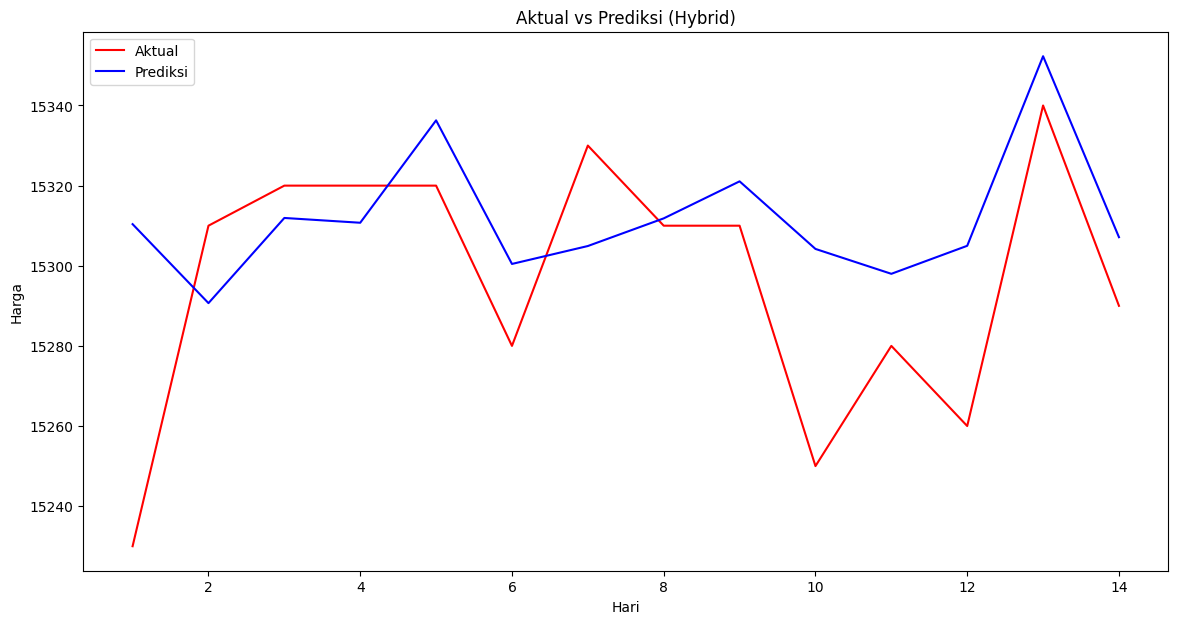

In [ ]:
plot_result_lstm('Hybrid', df_premium[-14:].values, hybrid_pred_val.values)

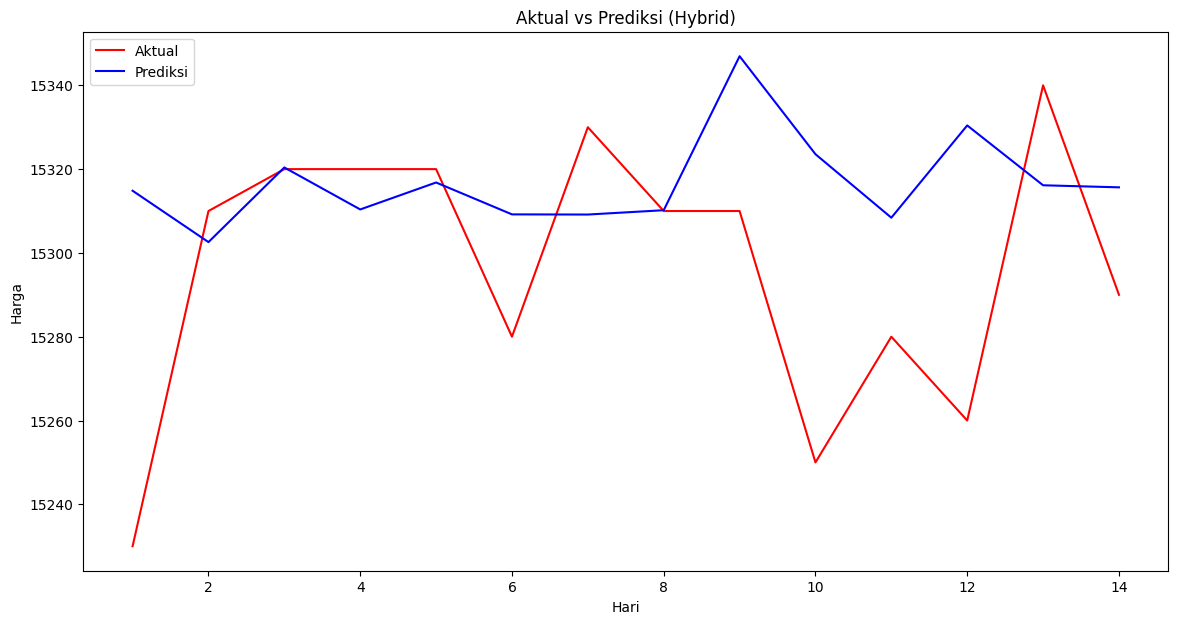

In [ ]:
plot_result_lstm('Hybrid', df_premium[-14:].values, hybrid_pred_val_70.values)

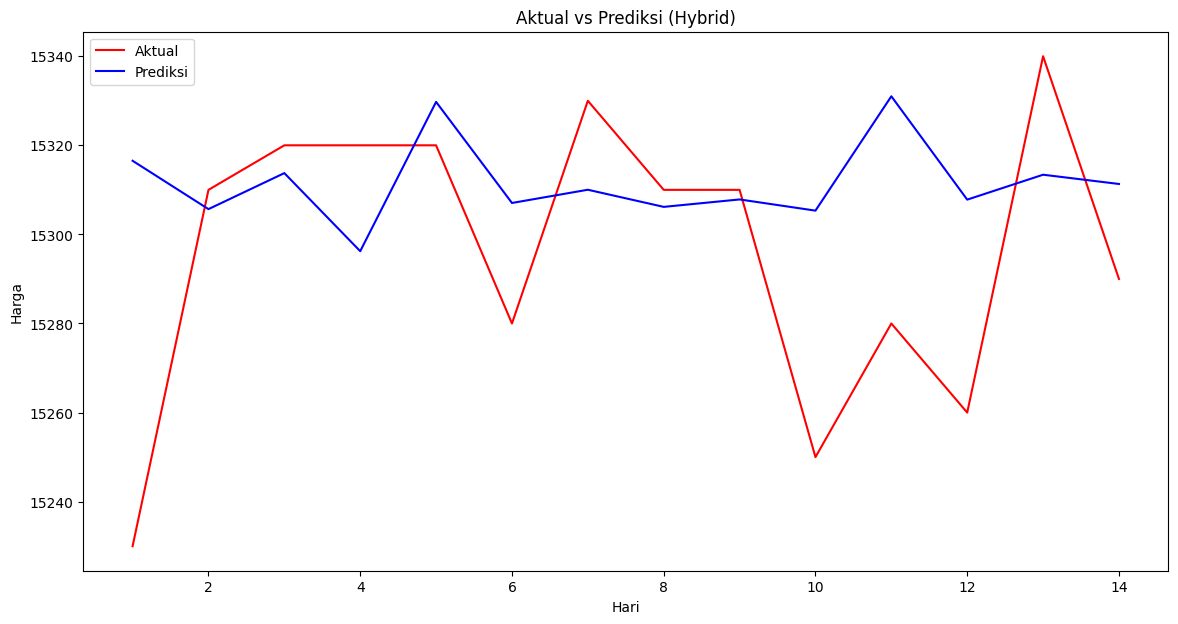

In [ ]:
plot_result_lstm('Hybrid', df_premium[-14:].values, hybrid_pred_val_60.values)

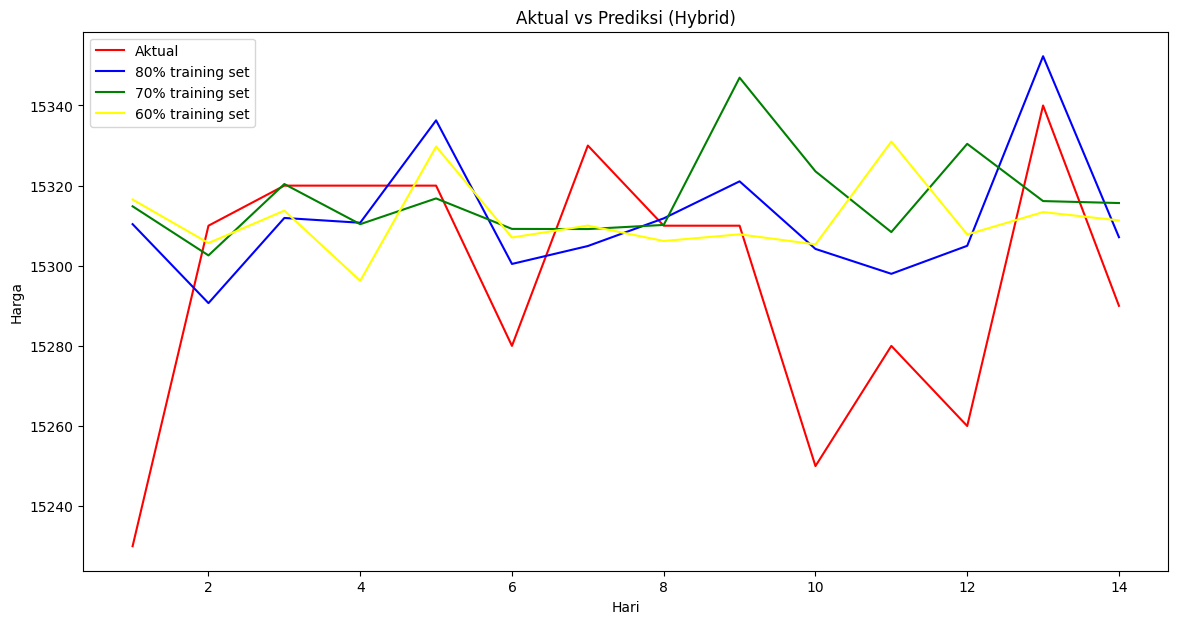

In [ ]:
plt.figure(figsize=(14, 7))
x_range = range(1, len(df_premium[-14:].values)+1)
plt.plot(x_range, df_premium[-14:].values, color ='red', label = 'Aktual')
plt.plot(x_range,  hybrid_pred_val.values, color = 'blue', label = '80% training set')
plt.plot(x_range,  hybrid_pred_val_70.values, color = 'green', label = '70% training set')
plt.plot(x_range,  hybrid_pred_val_60.values, color = 'yellow', label = '60% training set')
plt.title(f'Aktual vs Prediksi (Hybrid)')
plt.xlabel('Hari')
plt.ylabel('Harga')
plt.legend(['Aktual', '80% training set','70% training set','60% training set'], loc = 'upper left')
plt.show()

In [ ]:
#Export Model
joblib.dump(sarima_model, 'model_final_forecasting/hybrid/sarima_model_tr_hybrid.pkl')

['model_final_forecasting/hybrid/sarima_model_tr_hybrid.pkl']

In [ ]:
for i, model in enumerate(lstm_model):
  model.save(f'model_final_forecasting/hybrid/lstm_model_tr_{i}_hybrid.keras')

In [ ]:
model_auto2 = auto_arima(premium)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-11973.109, Time=0.14 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,1)[7]             : AIC=-11973.047, Time=2.42 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,1,1)(1,0,0)[7]             : AIC=-12079.109, Time=0.88 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(1,0,1)[7]             : AIC=-12077.116, Time=0.69 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(2,0,0)[7]             : AIC=-12078.713, Time=1.37 sec

Best model:  ARIMA(1,1,1)(3,0,0)[7]          
Total fit time: 139.257 seconds
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  687
Model:             SARIMAX(1, 1, 1)x(3, 0, [], 7)   Log Likelihood                6047.894
Date:                            Fri, 07 Feb 2025   AIC                         -12083.788
Time:                                    05:03:46   BIC                         -12056.602
Sample:                                07-15-2022   HQIC                        -12073.269
                                     - 05-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

In [ ]:
train_len2 = math.floor(len(y_resid)*0.80)

In [ ]:
# from tensorflow.keras.models import load_model
# def hybrid_final_model_fit(data, num_epoch, best_auto_am, scaller):
#   # best_lstm = tuner2.get_best_models(num_models=1)[0]
#   best_hps = tuner2.get_best_hyperparameters(num_trials=1)[0]
#   lr = best_hps.get('learning_rate')
#   best_order = best_auto_am.order
#   best_seasonal = best_auto_am.seasonal_order

#   sarima_model2 = SARIMAX(data, order = best_order, seasonal_order = best_seasonal).fit()
#   sarima_pred = sarima_model2.predict(start = data.index[0], end = data.index[-1])
#   sarima_pred = sarima_pred.to_frame(name='pred')
#   resid_scaled = residualForLstm(inv_boxcox(data, lmd), inv_boxcox(sarima_pred, lmd), scaller)

#   x, y = make_data_direct(resid_scaled, window_size, steps)
#   x = x[train_len2:]
#   y = y[train_len2:]

#   lstm_model2 = []
#   rows =  math.ceil(steps/2)
#   cols = 2
#   step_temp = 0

#   fig,axs = plt.subplots(rows, cols, figsize=(15, 30))
#   for i in range(rows):
#     for j in range(cols):
#       model = load_model(f'/content/drive/My Drive/Tugas Akhir/final_model2/premium/model_final_forecasting/hybrid/lstm_model_tr_{step_temp}_hybrid.keras')
#       model.compile(optimizer = keras.optimizers.Adam(learning_rate = lr*0.1),
#                            loss = 'mse', metrics = ['mae', 'mape'])
#       model, hist = fitting(model, x, y[:, (step_temp)], num_epoch, isHybrid = True, isUpdate = True)
#       lstm_model2.append(model)
#       if step_temp < steps:
#         ax = axs[i,j]
#         ax.plot(hist.history['loss'], label=f'Model Loss ({step_temp+1})')
#         ax.legend()
#         step_temp += 1
#       else:
#         fig.delaxes(axs[i,j])
#   plt.tight_layout()
#   plt.show()

#   return sarima_model2, lstm_model2

In [ ]:
keras.backend.clear_session()

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
def hybrid_final_model_fit(data, num_epoch, best_auto_am, scaller):
  # best_lstm = tuner2.get_best_models(num_models=1)[0]
  best_hps = tuner2.get_best_hyperparameters(num_trials=1)[0]
  lr = best_hps.get('learning_rate')
  best_order = best_auto_am.order
  best_seasonal = best_auto_am.seasonal_order

  sarima_model2= SARIMAX(data, order = best_order, seasonal_order = best_seasonal).fit()
  sarima_pred = sarima_model2.predict(start = data.index[0], end = data.index[-1])
  sarima_pred = sarima_pred.to_frame(name='pred')
  resid_scaled = residualForLstm(inv_boxcox(data, lmd), inv_boxcox(sarima_pred, lmd), scaller)

  x_all, y_all = make_data_direct(resid_scaled, window_size, steps)
  # x = x[train_len2:]
  # y = y[train_len2:]

  lstm_model2 = []
  rows =  math.ceil(steps/2)
  cols = 2
  step_temp = 0
  fig,axs = plt.subplots(rows, cols, figsize=(15, 30))
  for i in range(rows):
    for j in range(cols):
      if step_temp >= steps:
        fig.delaxes(axs[i, j])  # Hapus sumbu jika tidak ada model lagi
        continue
      # keras.backend.clear_session()
      checkpoint = ModelCheckpoint(f'lstm_model_final_{step_temp}_hybrid.keras',
                                   monitor='loss',
                                   save_best_only=True,
                                   save_weights_only=False,
                                   mode='min',
                                   verbose=0)
      model = build_model(best_hps)
      hist = model.fit(x=x_all, y=y_all[:, (step_temp)],
                       epochs = num_epoch,
                       batch_size=32,
                       callbacks=[checkpoint],
                       verbose=0)
      lstm_model2.append(model)

      ax = axs[i,j]
      ax.plot(hist.history['loss'], label=f'Model Loss ({step_temp+1})')
      ax.legend()
      step_temp += 1

  plt.tight_layout()
  plt.show()

  return sarima_model2, lstm_model2

In [ ]:
data = premium
sc3 = MinMaxScaler(feature_range = (0,1))

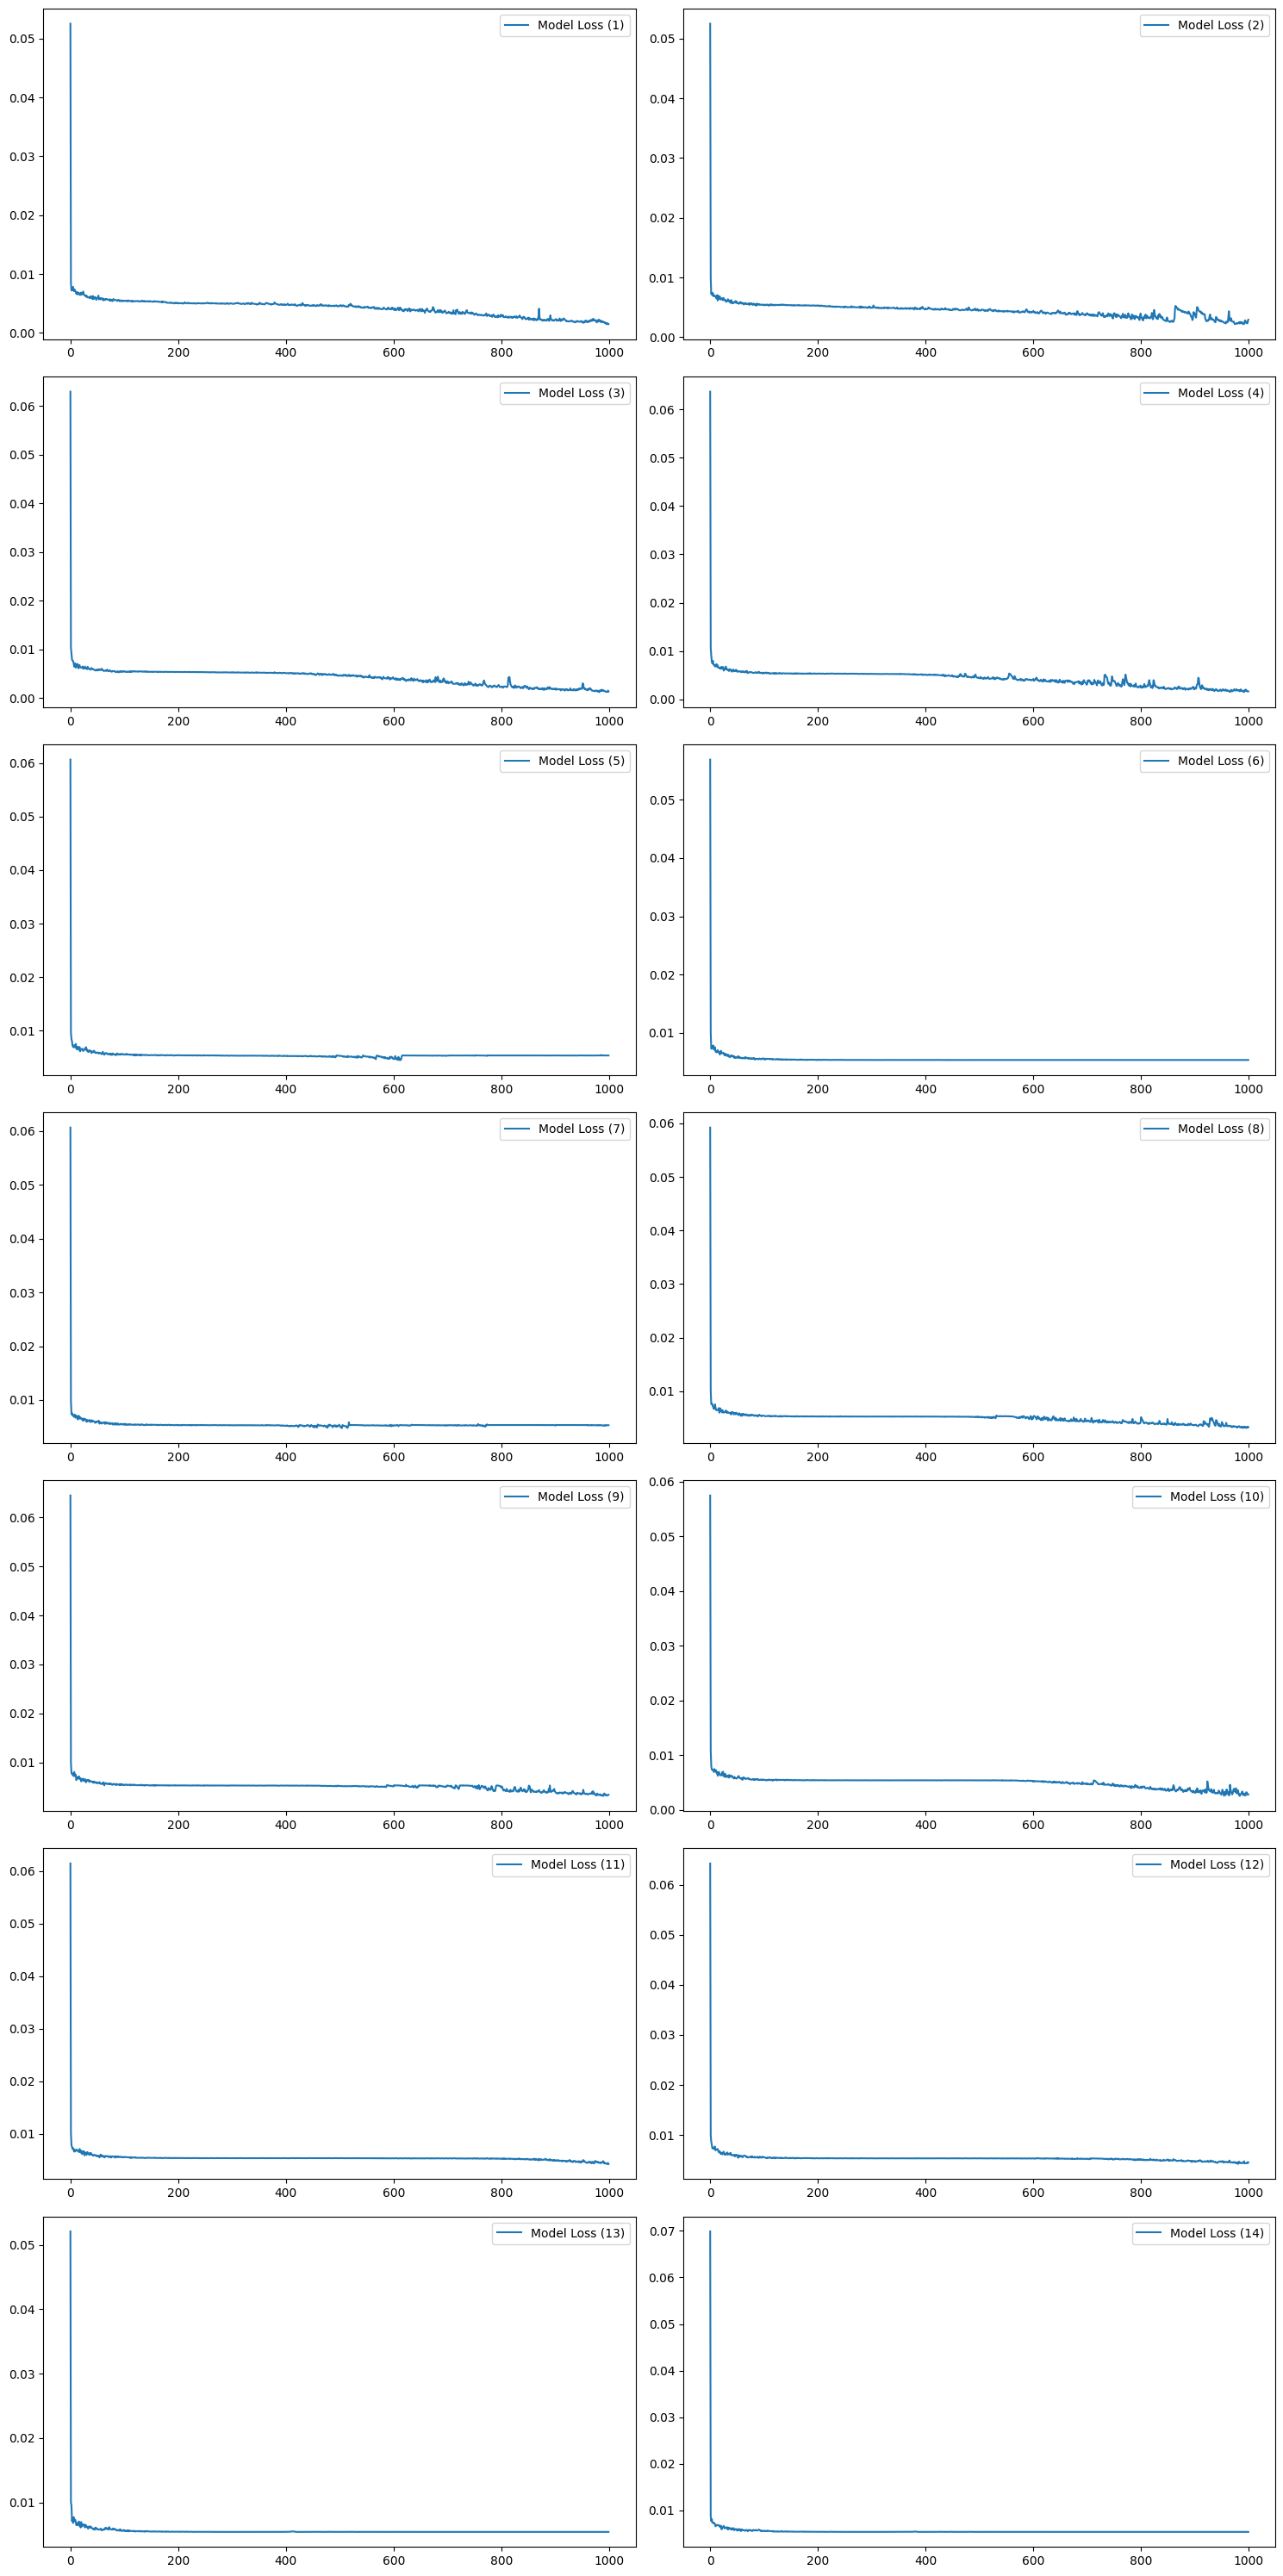

In [ ]:
#Fitting final model for forecasting
sarima_model2, lstm_model2= hybrid_final_model_fit(data, 1000, model_auto2, sc3)

In [ ]:
lstm_model3 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/My Drive/Tugas Akhir/final_model2_akhir6/premium/model_final_forecasting/lstm_model_final_{i}_hybrid.keras')
  lstm_model3.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()

sm_model = joblib.load('/content/drive/My Drive/Tugas Akhir/final_model2_akhir6/premium/model_final_forecasting/sarima_model_final_hybrid.pkl')

In [ ]:
def make_data_input_only(data, window_size):
  x_inp = []
  for i in range(len(data) - window_size + 1):
    x_inp.append(data[i:(i + window_size)])

  return np.array(x_inp)

In [ ]:
def hybrid_model_predict_final(sm_model, lm_model, X, scaller):
  sm_pred= sm_model.predict(start = X.index[0], end = X.index[-1])
  sm_forecast= sm_model.forecast(steps=14)
  sm_forecast = inv_boxcox(sm_forecast, lmd)
  data_temp = inv_boxcox(X, lmd)
  data_temp['pred'] = inv_boxcox(sm_pred, lmd)
  data_temp['residual'] = data_temp.iloc[:, 0] - data_temp.iloc[:, 1]
  residual = pd.DataFrame(data_temp['residual'][1:], columns=['residual'])
  resid_sc = scaller.fit_transform(residual)
  x1 = make_data_input_only(resid_sc, window_size)
  direct_pred = direct_lstm_pred(lm_model, x1, scaller, steps)

  direct_pred1 = direct_pred[direct_pred.shape[0]-1:]
  direct_pred1 = direct_pred1.transpose()
  all_pred = sm_forecast.to_frame()
  all_pred['resid_pred'] = direct_pred1
  all_pred['result'] =  all_pred.iloc[:,0] + all_pred.iloc[:,1]

  return all_pred['result'].to_frame(), residual, x1, direct_pred, data_temp['pred'],sm_forecast
  # return all_pred['result'].to_frame()

In [ ]:
final_pred, residual, x1, direct_pred, sm_pred, sm_forecast = hybrid_model_predict_final(sm_model, lstm_model3, data, sc3)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [ ]:
x1[-1:]

array([[[0.51989242],
        [0.57666238],
        [0.54687298],
        [0.67341573],
        [0.5906729 ]]])

In [ ]:
sm_forecast

,predicted_mean
2024-06-01,15297.808115
2024-06-02,15301.558267
2024-06-03,15299.279427
2024-06-04,15296.999950
2024-06-05,15296.826421
2024-06-06,15300.071322
2024-06-07,15302.389844
2024-06-08,15295.416639
2024-06-09,15301.187558
2024-06-10,15298.423824


In [ ]:
final_pred

,result
2024-06-01,15298.129267
2024-06-02,15287.522323
2024-06-03,15327.276698
2024-06-04,15296.900608
2024-06-05,15288.090570
2024-06-06,15298.077966
2024-06-07,15302.780303
2024-06-08,15304.169756
2024-06-09,15328.446719
2024-06-10,15328.829883


In [ ]:
premium_new = df_premium_new.copy()
premium_new['beras_premium'], lmd_new = stats.boxcox(premium_new['beras_premium'])
data_new = premium_new
sc_new = MinMaxScaler(feature_range = (0,1))

In [ ]:
# model_auto3 = auto_arima(data_new)
model_auto3 = auto_arima(data_new)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10

 ARIMA(0,1,0)(0,0,0)[7]             : AIC=57241.779, Time=0.23 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,1)[7]             : AIC=57243.788, Time=0.83 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,1,1)(1,0,0)[7]             : AIC=57189.530, Time=3.25 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(1,0,1)[7]             : AIC=57191.518, Time=3.29 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(2,0,0)[7]             : AIC=57191.395, Time=4.40 sec

Best model:  ARIMA(1,1,0)(0,0,0)[7]          
Total fit time: 128.511 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  901
Model:               SARIMAX(1, 1, 0)   Log Likelihood              -28588.810
Date:                Thu, 02 Jan 2025   AIC                          57181.620
Time:                        15:33:41   BIC                          57191.225
Sample:                    07-15-2022   HQIC                         57185.289
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1658      0.004    -45.786      0.000      -0.1

In [ ]:
sarima_model2= SARIMAX(data_new, order =  model_auto3.order, seasonal_order =  model_auto3.seasonal_order).fit()
sarima_pred = sarima_model2.forecast(steps=14)
sarima_pred = sarima_pred.to_frame(name='pred')
# resid_scaled = residualForLstm(inv_boxcox(data_new, lmd_new), inv_boxcox(sarima_pred, lmd_new), sc_new)
sarima_pred['result'] = inv_boxcox(sarima_pred, lmd_new)

In [ ]:
sarima_pred

,pred,result
2025-01-01,1.352608e+15,15279.050782
2025-01-02,1.352573e+15,15278.944429
2025-01-03,1.352887e+15,15279.890160
2025-01-04,1.352862e+15,15279.813875
2025-01-05,1.352966e+15,15280.127777
2025-01-06,1.352886e+15,15279.885421
2025-01-07,1.353038e+15,15280.343432
2025-01-08,1.352998e+15,15280.223524
2025-01-09,1.353006e+15,15280.248708
2025-01-10,1.353020e+15,15280.290968


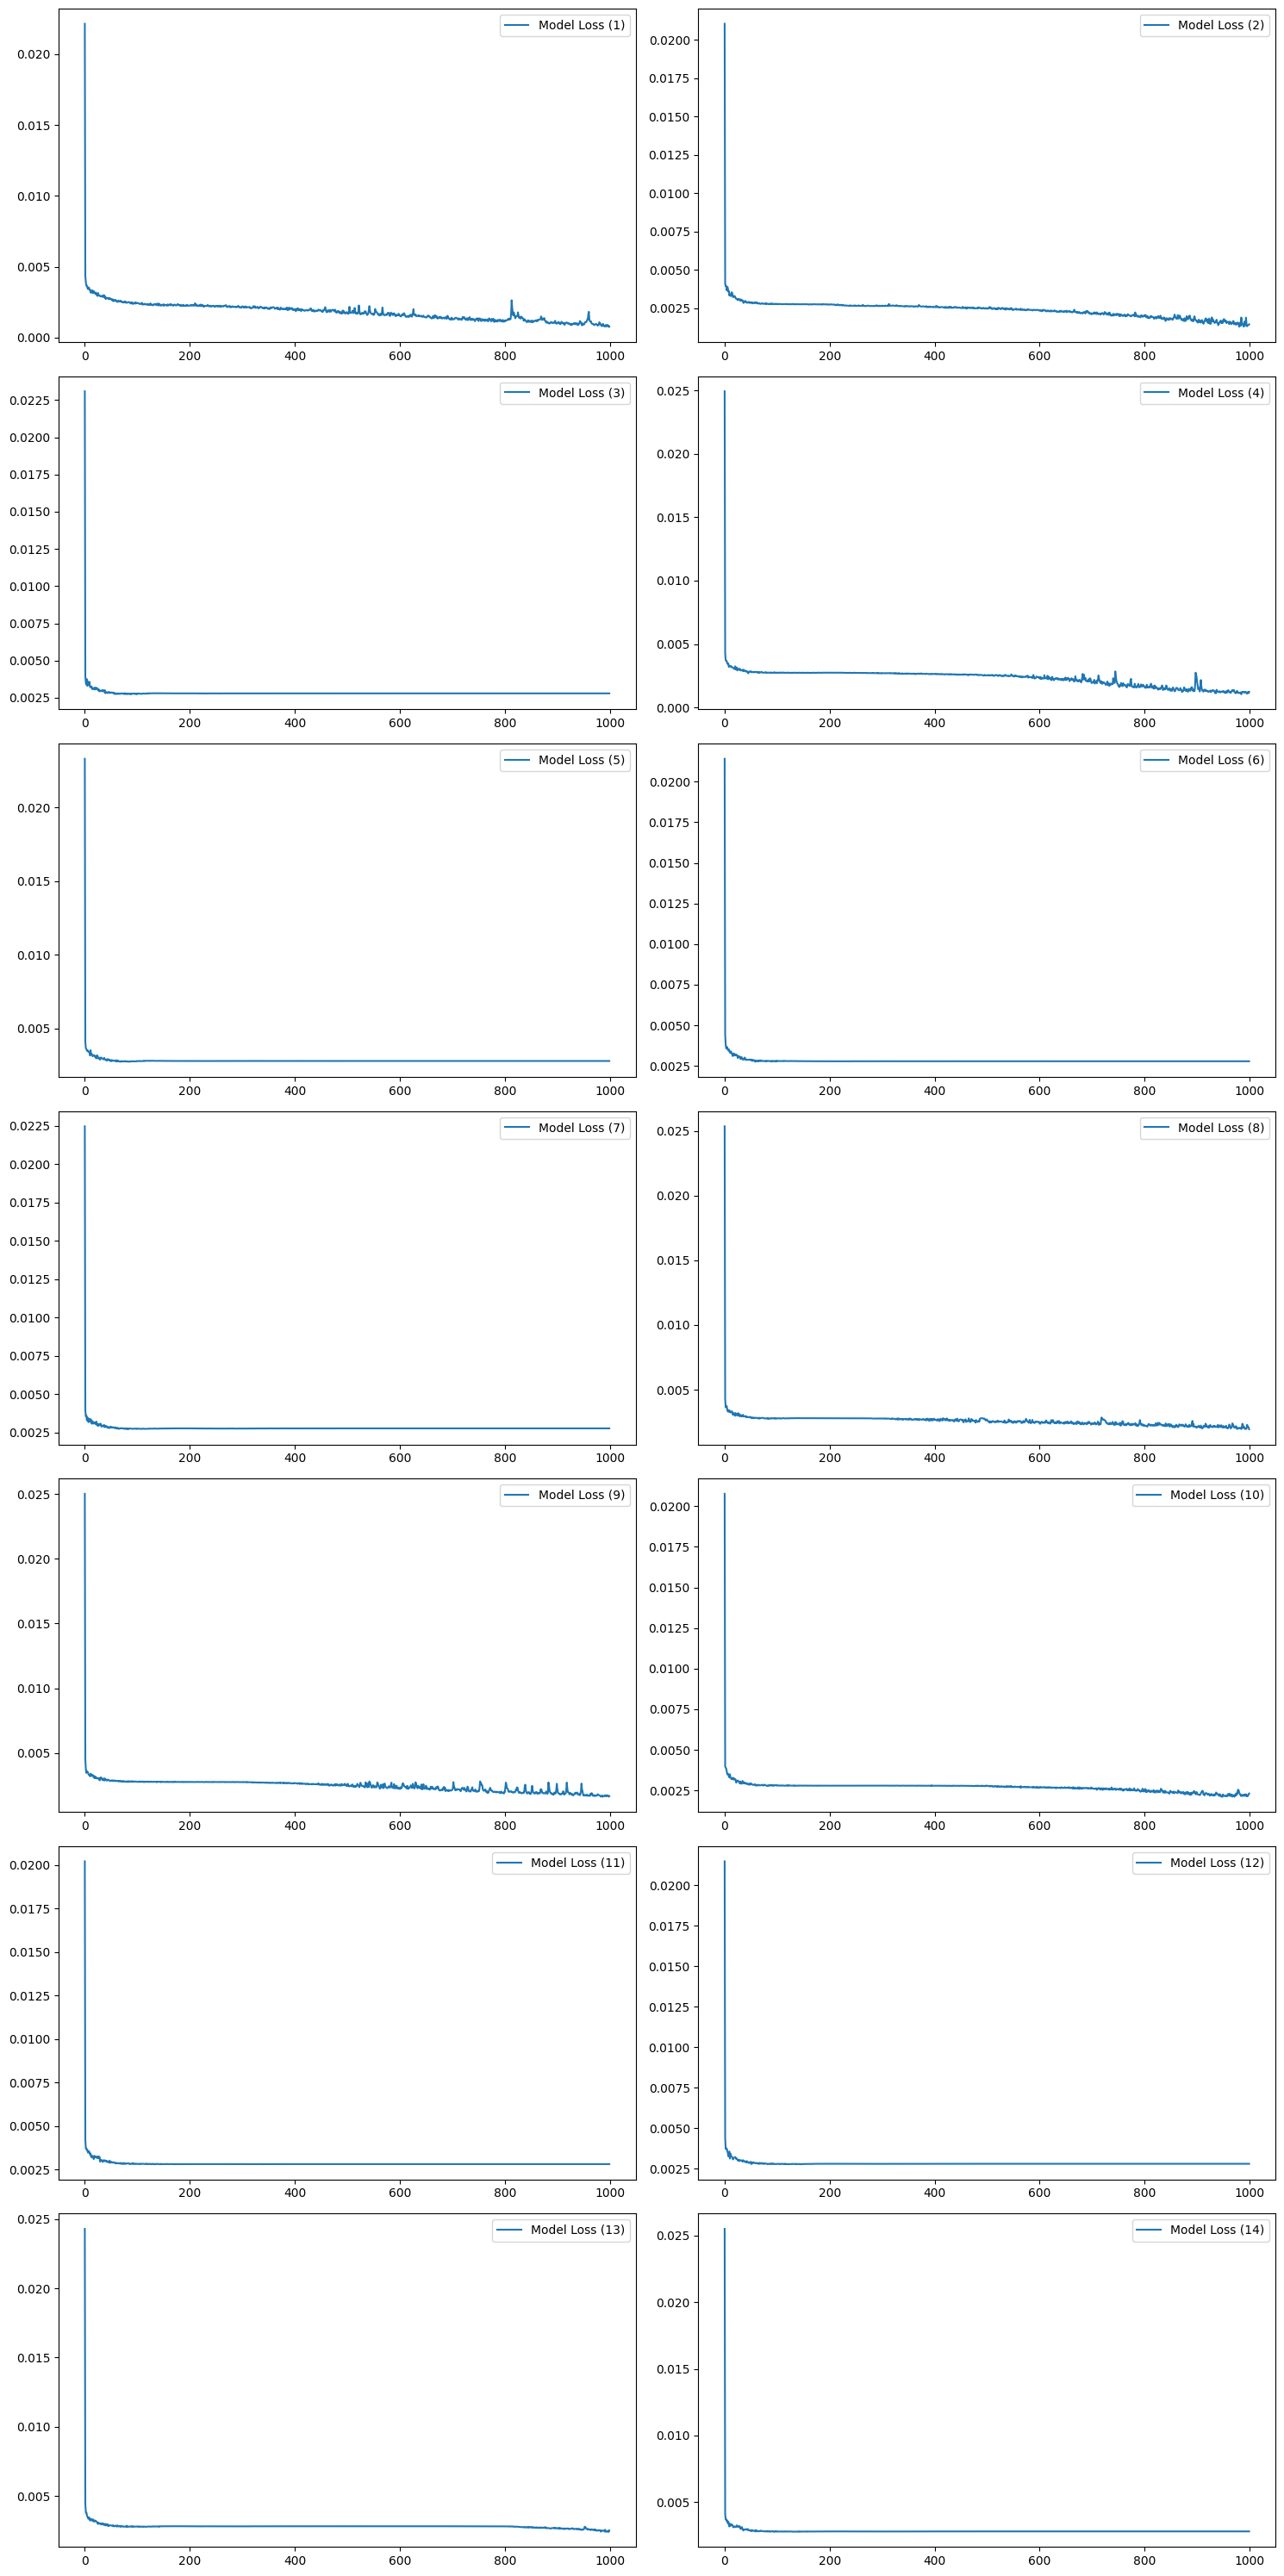

In [ ]:
sarima_model_new, lstm_model_new= hybrid_final_model_fit(data_new, 1000, model_auto3, sc_new, lmd_new)

In [ ]:
lstm_model4 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'lstm_model_final_{i}_hybrid.keras')
  # model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2_akhir4/premium/model_final_forecasting3/lstm_model_final_{i}_hybrid.keras')
  lstm_model4.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()
# sarima_model4 = joblib.load(f'/content/drive/MyDrive/Tugas Akhir/final_model2_akhir4/premium/model_final_forecasting3/sarima_model_final_hybrid.pkl')
# sc4 = joblib.load(f'/content/drive/MyDrive/Tugas Akhir/final_model2_akhir4/premium/model_final_forecasting3/scaller_final_hybrid.pkl')

In [ ]:
final_pred = hybrid_model_predict_final(sarima_model_new, lstm_model_new, data_new, sc4, lmd_new)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
final_pred

,result
2025-01-01,15228.264135
2025-01-02,15256.703814
2025-01-03,15279.680036
2025-01-04,15301.113435
2025-01-05,15276.730314
2025-01-06,15285.955973
2025-01-07,15282.546069
2025-01-08,15252.187399
2025-01-09,15296.878493
2025-01-10,15314.656925


In [ ]:
import os

os.makedirs('model_final_forecasting3', exist_ok=True)
joblib.dump(sc_new, 'model_final_forecasting3/scaller_final_hybrid.pkl')
#Export Model
joblib.dump(sarima_model_new, 'model_final_forecasting3/sarima_model_final_hybrid.pkl')
for i, model in enumerate(lstm_model4):
  model.save(f'model_final_forecasting3/lstm_model_final_{i}_hybrid.keras')
for i, model in enumerate(lstm_model_new):
  model.save(f'model_final_forecasting3/lstm_model_final_{i}_hybrid1.keras')
  #Export Model
joblib.dump(model_auto3, 'model_final_forecasting3/autoarima_final.pkl')

['model_final_forecasting3/autoarima_final.pkl']

In [ ]:
# import os
source_dir = 'model_final_forecasting3'

target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2_akhir5/premium/model_final_forecasting3'

shutil.copytree(source_dir, target_dir)

'/content/drive/My Drive/Tugas Akhir/final_model2_akhir5/premium/model_final_forecasting3'

In [ ]:
import os

os.makedirs('model_final_forecasting2', exist_ok=True)

In [ ]:
joblib.dump(sc3, 'model_final_forecasting2/scaller_final_hybrid.pkl')

['model_final_forecasting2/scaller_final_hybrid.pkl']

In [ ]:
#Export Model
joblib.dump(sarima_model2, 'model_final_forecasting2/sarima_model_final_hybrid.pkl')

['model_final_forecasting2/sarima_model_final_hybrid.pkl']

In [ ]:
for i, model in enumerate(lstm_model3):
  model.save(f'model_final_forecasting2/lstm_model_final_{i}_hybrid.keras')

In [ ]:
#Export Model
joblib.dump(model_auto, 'model_final_forecasting2/autoarima_tr.pkl')
joblib.dump(model_auto2, 'model_final_forecasting2/autoarima_final.pkl')

['model_final_forecasting2/autoarima_final.pkl']

In [ ]:
# import os
source_dir = 'model_final_forecasting'

target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/premium/model_final_forecasting'

shutil.copytree(source_dir, target_dir)

In [ ]:
# import os
source_dir = 'model_final_forecasting2'

target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2_akhir3/premium/model_final_forecasting2'

shutil.copytree(source_dir, target_dir)

'/content/drive/My Drive/Tugas Akhir/final_model2_akhir3/premium/model_final_forecasting2'